# Research Model Training

This notebook maps `Scripts/project/scripts/train_research_paper_ensemble.py` into a Jupyter workflow.

It uses only local project data:
- `data/centralData/arabica_ml_model_ready.csv`
- local COT/weather features already included in the prepared dataset
- local GDELT event data when present
- paper conclusions referenced in the script manifest

In [ ]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "data").exists():
    ROOT = ROOT.parent

PYTHON = sys.executable
DATA_PATH = ROOT / "data" / "centralData" / "arabica_ml_model_ready.csv"
SCRIPT_PATH = ROOT / "Scripts" / "project" / "scripts" / "train_research_paper_ensemble.py"
OUTPUTS_DIR = ROOT / "Scripts" / "project" / "artifacts" / "outputs"
PLOTS_DIR = ROOT / "Scripts" / "project" / "artifacts" / "plots"
MODELS_DIR = ROOT / "Scripts" / "project" / "artifacts" / "models"

def run_script(*args):
    cmd = [PYTHON, *args]
    print(" ".join(str(part) for part in cmd))
    result = subprocess.run(cmd, cwd=ROOT, text=True, capture_output=True)
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    result.check_returncode()

print(f"Project root: {ROOT}")
print(f"Python: {PYTHON}")
print(f"Training data exists: {DATA_PATH.exists()} - {DATA_PATH}")

## 1. Data Check

In [ ]:
ready = pd.read_csv(DATA_PATH, parse_dates=["Date"], low_memory=False)
core_columns = ["Date", "Close", "High", "Low", "Open", "Volume"]
feature_columns = [c for c in ready.columns if c not in core_columns and not c.startswith("target_")]

summary = {
    "rows": len(ready),
    "columns": len(ready.columns),
    "unique_dates": ready["Date"].nunique(),
    "date_start": ready["Date"].min().date().isoformat(),
    "date_end": ready["Date"].max().date().isoformat(),
    "core_missing_cells": int(ready[core_columns].isna().sum().sum()),
    "feature_columns": len(feature_columns),
    "weather_columns": len([c for c in ready.columns if c.startswith("weather_")]),
    "target_return_5d_rows": int(ready["target_return_5d"].notna().sum()),
}
summary

## 2. Train Paper-Inspired Models and Final Ensemble

Set `FAST_RUN = True` for a quicker smoke run. Leave it `False` for the full due-diligence run with cross-validation, ROC, confusion matrices, RMSE/MAE/R2, regime analysis, volatility checks, and plots.

In [3]:
FAST_RUN = False
SKIP_EVENTS = False
SKIP_XGBOOST = False

cmd = [
    PYTHON,
    str(SCRIPT_PATH.relative_to(ROOT)),
    "--data", str(DATA_PATH.relative_to(ROOT)),
]
if FAST_RUN:
    cmd.append("--fast")
if SKIP_EVENTS:
    cmd.append("--skip-events")
if SKIP_XGBOOST:
    cmd.append("--skip-xgboost")

print(" ".join(cmd))
result = subprocess.run(cmd, cwd=ROOT, text=True, capture_output=True)
print(result.stdout)
if result.stderr:
    print(result.stderr)
result.check_returncode()

Building leak-safe daily GDELT features from local events...
Rows: train=4674, validation=998, test=1003; models=17; features=248
Evaluating paper-inspired models on validation...
  [01/17] zero_return: RMSE=0.050479, direction=0.489
  [02/17] ar_ridge: RMSE=0.050537, direction=0.546
  [03/17] arima_111: RMSE=0.050489, direction=0.498
  [04/17] simple_exp_smoothing: RMSE=0.050465, direction=0.510
  [05/17] holt_winters_5d: RMSE=0.050507, direction=0.515
  [06/17] linear_trend_252d: RMSE=0.099579, direction=0.515
  [07/17] quadratic_trend_252d: RMSE=0.088008, direction=0.544
  [08/17] linear_technical: RMSE=0.050815, direction=0.516
  [09/17] random_forest_technical: RMSE=0.050492, direction=0.531
  [10/17] mlp_price_history: RMSE=0.063034, direction=0.494
  [11/17] elm_price_history: RMSE=0.050953, direction=0.539
  [12/17] hedonic_weather_cot_ridge: RMSE=0.056631, direction=0.508
  [13/17] threshold_ar_npi: RMSE=0.050850, direction=0.500
  [14/17] cot_contract_stress_forest: RMSE=0.05

## 3. Compare Metrics

In [4]:
metrics_path = OUTPUTS_DIR / "research_paper_ensemble_metrics.json"
comparison_path = OUTPUTS_DIR / "research_paper_model_comparison.csv"
cv_summary_path = OUTPUTS_DIR / "research_paper_model_cv_summary.csv"
regime_metrics_path = OUTPUTS_DIR / "research_paper_regime_metrics.csv"

metrics = json.loads(metrics_path.read_text())
comparison = pd.read_csv(comparison_path)
cv_summary = pd.read_csv(cv_summary_path)
regime_metrics = pd.read_csv(regime_metrics_path)

comparison.loc[comparison["phase"].eq("test")].sort_values(["rmse", "mae", "directional_accuracy"], ascending=[True, True, False])[
    ["model", "approach", "rmse", "mae", "r2", "directional_accuracy", "balanced_accuracy", "roc_auc", "average_precision", "strategy_sharpe"]
].reset_index(drop=True)

,model,approach,rmse,mae,r2,directional_accuracy,balanced_accuracy,roc_auc,average_precision,strategy_sharpe
0,xgboost_regime_aware,"XGBoost with past-only volatility, trend, liqu...",0.051887,0.040156,0.050042,0.611167,0.611104,0.643255,0.639626,1.762009
1,xgboost_integrated,"Integrated nonlinear model using price, COT, w...",0.052006,0.040173,0.045695,0.614158,0.614075,0.643816,0.652175,1.722130
2,cot_contract_stress_forest,"COT crowding, reversal, contract-shock, and de...",0.052311,0.041069,0.034450,0.578265,0.578152,0.607224,0.599671,1.713296
3,arima_111,"ARIMA(1,1,1) on log price with walk-forward st...",0.053303,0.042273,-0.002488,0.503490,0.503940,0.496286,0.499351,0.692621
4,zero_return,No-change return benchmark,0.053330,0.042273,-0.003528,0.500499,0.500000,0.500000,0.499501,NaN
5,simple_exp_smoothing,Simple exponential smoothing on log price,0.053337,0.042270,-0.003781,0.497507,0.497509,0.495988,0.498960,-0.562072
6,ar_ridge,Autoregressive return benchmark,0.053389,0.042285,-0.005731,0.487537,0.487593,0.508930,0.515739,-0.140065
7,holt_winters_5d,Additive Holt-Winters with five-trading-day se...,0.053392,0.042401,-0.005864,0.495513,0.495922,0.468843,0.478566,-0.169623
8,research_ensemble,Validation-optimized non-negative blend,0.053443,0.042291,-0.007787,0.501496,0.501457,0.509407,0.481464,0.338478
9,threshold_ar_npi,Threshold autoregression using the NPI/PER pro...,0.053576,0.042565,-0.012781,0.509472,0.509574,0.498410,0.492808,0.641636


In [5]:
direction_metric_columns = [
    "model",
    "rmse",
    "directional_accuracy",
    "balanced_accuracy",
    "roc_auc",
    "precision_positive",
    "recall_positive",
    "f1_positive",
    "matthews_correlation",
]
available_direction_metric_columns = [col for col in direction_metric_columns if col in comparison.columns]

comparison.loc[comparison["phase"].eq("test")].sort_values(
    ["directional_accuracy", "roc_auc"], ascending=False
)[available_direction_metric_columns].reset_index(drop=True)

,model,rmse,directional_accuracy,balanced_accuracy,roc_auc,precision_positive,recall_positive,f1_positive,matthews_correlation
0,xgboost_integrated,0.052006,0.614158,0.614075,0.643816,0.636364,0.530938,0.578890,0.231379
1,xgboost_regime_aware,0.051887,0.611167,0.611104,0.643255,0.626424,0.548902,0.585106,0.223955
2,cot_contract_stress_forest,0.052311,0.578265,0.578152,0.607224,0.600515,0.465070,0.524184,0.160469
3,hist_gradient_boosting_integrated,0.054150,0.563310,0.563258,0.601474,0.570156,0.510978,0.538947,0.127215
4,elm_price_history,0.054014,0.517448,0.517489,0.535141,0.515654,0.558882,0.536398,0.035098
5,mlp_price_history,0.059495,0.515454,0.515437,0.519236,0.515464,0.499002,0.507099,0.030891
6,linear_technical,0.053829,0.511466,0.511336,0.541244,0.514825,0.381238,0.438073,0.023481
7,threshold_ar_npi,0.053576,0.509472,0.509574,0.498410,0.507438,0.612774,0.555154,0.019570
8,hedonic_weather_cot_ridge,0.061498,0.506481,0.506083,0.476744,0.529412,0.107784,0.179104,0.020127
9,arima_111,0.053303,0.503490,0.503940,0.496286,0.501571,0.956088,0.657967,0.018459


In [6]:
cv_summary.sort_values(["rmse_mean", "directional_accuracy_mean"], ascending=[True, False]).reset_index(drop=True)

,model,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std,directional_accuracy_mean,directional_accuracy_std,roc_auc_mean,roc_auc_std,strategy_sharpe_mean,strategy_sharpe_std
0,simple_exp_smoothing,0.046856,0.005564,0.035880,0.003189,-0.004491,0.005707,0.499295,0.011596,0.510645,0.007201,-0.074064,0.185209
1,zero_return,0.046856,0.005561,0.035879,0.003193,-0.004521,0.006096,0.524665,0.040034,0.500000,0.000000,NaN,NaN
2,arima_111,0.046893,0.005582,0.035963,0.003229,-0.006002,0.005332,0.474630,0.042124,0.510450,0.006739,0.029363,0.309373
3,holt_winters_5d,0.046974,0.005576,0.036003,0.003210,-0.009552,0.004492,0.482382,0.043099,0.485702,0.031545,-0.156887,0.533682
4,threshold_ar_npi,0.047565,0.005790,0.036620,0.003434,-0.034675,0.018008,0.477801,0.027095,0.487633,0.009824,0.082051,0.463002
5,ar_ridge,0.047662,0.005955,0.036405,0.003364,-0.038748,0.042323,0.505285,0.040708,0.532262,0.017373,0.035162,0.816644
6,random_forest_technical,0.048021,0.006428,0.036956,0.003959,-0.053736,0.071195,0.510571,0.024723,0.535387,0.017746,0.200834,0.556898
7,linear_technical,0.048074,0.005070,0.036920,0.002701,-0.060001,0.033546,0.479563,0.028173,0.509834,0.040314,-0.196205,0.142675
8,xgboost_integrated,0.048662,0.008357,0.037937,0.006915,-0.082973,0.193695,0.541226,0.074717,0.602200,0.018100,0.708046,0.783169
9,elm_price_history,0.048668,0.005609,0.037407,0.003607,-0.085355,0.057767,0.518675,0.021177,0.532978,0.022696,0.139396,0.456330


## 4. Regime Diagnostics

In [7]:
regime_display = regime_metrics.copy()
if "rmse_improvement_vs_zero_pct" not in regime_display.columns and {"rmse", "zero_return_rmse"}.issubset(regime_display.columns):
    regime_display["rmse_improvement_vs_zero_pct"] = (
        regime_display["zero_return_rmse"] - regime_display["rmse"]
    ) / regime_display["zero_return_rmse"]

regime_columns = [
    "phase",
    "regime_family",
    "regime",
    "model",
    "rows",
    "rmse",
    "zero_return_rmse",
    "rmse_improvement_vs_zero_pct",
    "directional_accuracy",
    "directional_accuracy_minus_majority",
    "roc_auc",
]
available_regime_columns = [col for col in regime_columns if col in regime_display.columns]

regime_display.loc[regime_display["phase"].eq("test")].sort_values(
    ["rmse_improvement_vs_zero_pct", "directional_accuracy"], ascending=False
)[available_regime_columns].head(25)

,phase,regime_family,regime,model,rows,rmse,zero_return_rmse,rmse_improvement_vs_zero_pct,directional_accuracy,directional_accuracy_minus_majority,roc_auc
1096,test,calendar_year,2023,xgboost_regime_aware,251,0.044269,0.048079,0.079248,0.629482,0.107570,0.704198
1094,test,calendar_year,2023,hist_gradient_boosting_integrated,251,0.044436,0.048079,0.075764,0.629482,0.107570,0.704453
1095,test,calendar_year,2023,xgboost_integrated,251,0.044498,0.048079,0.074480,0.641434,0.119522,0.706107
987,test,trend_volatility_regime,range__low_volatility,xgboost_integrated,21,0.064857,0.069428,0.065841,0.666667,0.095238,0.694444
754,test,liquidity_regime,high_volume,xgboost_regime_aware,323,0.047177,0.050457,0.065004,0.650155,0.136223,0.708081
1093,test,calendar_year,2023,cot_contract_stress_forest,251,0.044990,0.048079,0.064238,0.657371,0.135458,0.705216
933,test,trend_volatility_regime,downtrend__low_volatility,xgboost_integrated,41,0.046318,0.049460,0.063532,0.560976,0.048780,0.659524
897,test,brazil_weather_regime,weather_stress,xgboost_integrated,552,0.047281,0.050487,0.063500,0.664855,0.161232,0.715263
1036,test,trend_volatility_regime,uptrend__low_volatility,elm_price_history,32,0.060967,0.065037,0.062581,0.718750,0.062500,0.748918
988,test,trend_volatility_regime,range__low_volatility,xgboost_regime_aware,21,0.065095,0.069428,0.062421,0.571429,0.000000,0.638889


## 5. Yahoo Real Price Comparison

Compare each model prediction with the actual Yahoo Finance 5-trading-day future close and return on the untouched holdout period.

In [8]:
predictions_path = OUTPUTS_DIR / "research_paper_model_holdout_predictions.csv"
predictions = pd.read_csv(predictions_path, parse_dates=["Date"])

predicted_return_columns = [c for c in predictions.columns if c.endswith("_predicted_return_5d")]
real_comparison_rows = []
for return_col in predicted_return_columns:
    model = return_col.removesuffix("_predicted_return_5d")
    close_col = f"{model}_predicted_close_5d"
    direction_col = f"{model}_predicted_direction_5d"
    if close_col not in predictions.columns:
        continue
    valid = predictions[["target_return_5d", "target_close_5d", return_col, close_col]].dropna()
    if valid.empty:
        continue
    real_direction = valid["target_return_5d"] > 0
    predicted_direction = valid[return_col] > 0
    real_comparison_rows.append({
        "model": model,
        "rows": len(valid),
        "actual_return_mean": valid["target_return_5d"].mean(),
        "predicted_return_mean": valid[return_col].mean(),
        "return_error_mean": (valid[return_col] - valid["target_return_5d"]).mean(),
        "return_mae": (valid[return_col] - valid["target_return_5d"]).abs().mean(),
        "return_rmse": ((valid[return_col] - valid["target_return_5d"]) ** 2).mean() ** 0.5,
        "close_mae": (valid[close_col] - valid["target_close_5d"]).abs().mean(),
        "close_rmse": ((valid[close_col] - valid["target_close_5d"]) ** 2).mean() ** 0.5,
        "directional_accuracy": (real_direction == predicted_direction).mean(),
        "actual_up_rate": real_direction.mean(),
        "predicted_up_rate": predicted_direction.mean(),
    })

real_yahoo_comparison = pd.DataFrame(real_comparison_rows).sort_values(
    ["return_rmse", "directional_accuracy"], ascending=[True, False]
).reset_index(drop=True)

real_yahoo_comparison_path = OUTPUTS_DIR / "research_paper_real_yahoo_comparison.csv"
real_yahoo_comparison.to_csv(real_yahoo_comparison_path, index=False)
print(f"Saved: {real_yahoo_comparison_path.relative_to(ROOT)}")
real_yahoo_comparison

Saved: Scripts/project/artifacts/outputs/research_paper_real_yahoo_comparison.csv


,model,rows,actual_return_mean,predicted_return_mean,return_error_mean,return_mae,return_rmse,close_mae,close_rmse,directional_accuracy,actual_up_rate,predicted_up_rate
0,xgboost_regime_aware,1003,0.003162,-0.002884,-0.006047,0.040156,0.051887,10.730196,14.867280,0.611167,0.499501,0.437687
1,xgboost_integrated,1003,0.003162,-0.003255,-0.006417,0.040173,0.052006,10.753683,14.932767,0.614158,0.499501,0.416750
2,cot_contract_stress_forest,1003,0.003162,-0.002272,-0.005434,0.041069,0.052311,11.004664,15.032125,0.578265,0.499501,0.386839
3,arima_111,1003,0.003162,0.000627,-0.002536,0.042273,0.053303,11.281100,15.241321,0.503490,0.499501,0.952144
4,zero_return,1003,0.003162,0.000000,-0.003162,0.042273,0.053330,11.278664,15.240070,0.500499,0.499501,0.000000
5,simple_exp_smoothing,1003,0.003162,-0.000006,-0.003168,0.042270,0.053337,11.277511,15.241129,0.497507,0.499501,0.501496
6,ar_ridge,1003,0.003162,0.000465,-0.002697,0.042285,0.053389,11.241709,15.163070,0.487537,0.499501,0.555334
7,holt_winters_5d,1003,0.003162,0.002002,-0.001160,0.042401,0.053392,11.327862,15.297546,0.495513,0.499501,0.910269
8,research_ensemble,1003,0.003162,-0.001163,-0.004325,0.042291,0.053443,11.256963,15.232794,0.501496,0.499501,0.461615
9,threshold_ar_npi,1003,0.003162,0.001025,-0.002137,0.042565,0.053576,11.339141,15.298914,0.509472,0.499501,0.603190


In [9]:
# Date-level comparison for the best few models by return RMSE.
top_models = real_yahoo_comparison.head(4)["model"].tolist()
yahoo_date_comparison = predictions[["Date", "Close", "target_close_5d", "target_return_5d", "target_direction_5d"]].copy()
for model in top_models:
    yahoo_date_comparison[f"{model}_predicted_return_5d"] = predictions[f"{model}_predicted_return_5d"]
    yahoo_date_comparison[f"{model}_predicted_close_5d"] = predictions[f"{model}_predicted_close_5d"]
    yahoo_date_comparison[f"{model}_close_error"] = yahoo_date_comparison[f"{model}_predicted_close_5d"] - yahoo_date_comparison["target_close_5d"]

yahoo_date_comparison_path = OUTPUTS_DIR / "research_paper_real_yahoo_date_comparison.csv"
yahoo_date_comparison.to_csv(yahoo_date_comparison_path, index=False)
print(f"Saved: {yahoo_date_comparison_path.relative_to(ROOT)}")
yahoo_date_comparison.tail(20)

Saved: Scripts/project/artifacts/outputs/research_paper_real_yahoo_date_comparison.csv


,Date,Close,target_close_5d,target_return_5d,target_direction_5d,xgboost_regime_aware_predicted_return_5d,xgboost_regime_aware_predicted_close_5d,xgboost_regime_aware_close_error,xgboost_integrated_predicted_return_5d,xgboost_integrated_predicted_close_5d,xgboost_integrated_close_error,cot_contract_stress_forest_predicted_return_5d,cot_contract_stress_forest_predicted_close_5d,cot_contract_stress_forest_close_error,arima_111_predicted_return_5d,arima_111_predicted_close_5d,arima_111_close_error
983,2026-08-05,326.899994,340.100006,0.040379,1.0,-0.018501,320.852167,-19.247839,-0.022998,319.381990,-20.718016,-0.016135,321.625403,-18.474603,0.000496,327.062019,-13.037987
984,2026-08-06,321.649994,333.100006,0.035598,1.0,0.012000,325.509657,-7.590349,0.005911,323.551384,-9.548622,0.005136,323.301880,-9.798126,0.000886,321.934966,-11.165041
985,2026-08-07,335.549988,338.100006,0.007600,1.0,0.002219,336.294666,-1.805340,-0.005429,333.728390,-4.371616,0.005605,337.430876,-0.669130,-0.000030,335.539787,-2.560219
986,2026-08-10,332.299988,345.100006,0.038519,1.0,0.010300,335.722573,-9.377433,0.000823,332.573425,-12.526581,0.009718,335.529354,-9.570652,0.000781,332.559362,-12.540644
987,2026-08-11,335.750000,363.399994,0.082353,1.0,0.007522,338.275529,-25.124465,0.005118,337.468479,-25.931515,0.005928,337.740345,-25.659649,0.000471,335.908219,-27.491775
988,2026-08-12,340.100006,359.500000,0.057042,1.0,0.010477,343.663169,-15.836831,0.003726,341.367116,-18.132884,0.008854,343.111115,-16.388885,0.000429,340.245897,-19.254103
989,2026-08-13,333.100006,363.600006,0.091564,1.0,0.010000,336.431109,-27.168897,0.002241,333.846450,-29.753556,0.009304,336.199221,-27.400786,0.000958,333.419083,-30.180923
990,2026-08-14,338.100006,358.750000,0.061077,1.0,-0.003798,336.815876,-21.934124,-0.007703,335.495501,-23.254499,0.008049,340.821355,-17.928645,0.000401,338.235495,-20.514505
991,2026-08-17,345.100006,377.750000,0.094610,1.0,0.006463,347.330365,-30.419635,0.006101,347.205545,-30.544455,0.010391,348.686074,-29.063926,0.000309,345.206541,-32.543459
992,2026-08-18,363.399994,371.399994,0.022014,1.0,-0.005038,361.569353,-9.830641,0.002054,364.146415,-7.253579,0.004089,364.885995,-6.513998,-0.000182,363.333950,-8.066044


Saved: Scripts/project/artifacts/plots/research_paper_real_yahoo_close_comparison.png


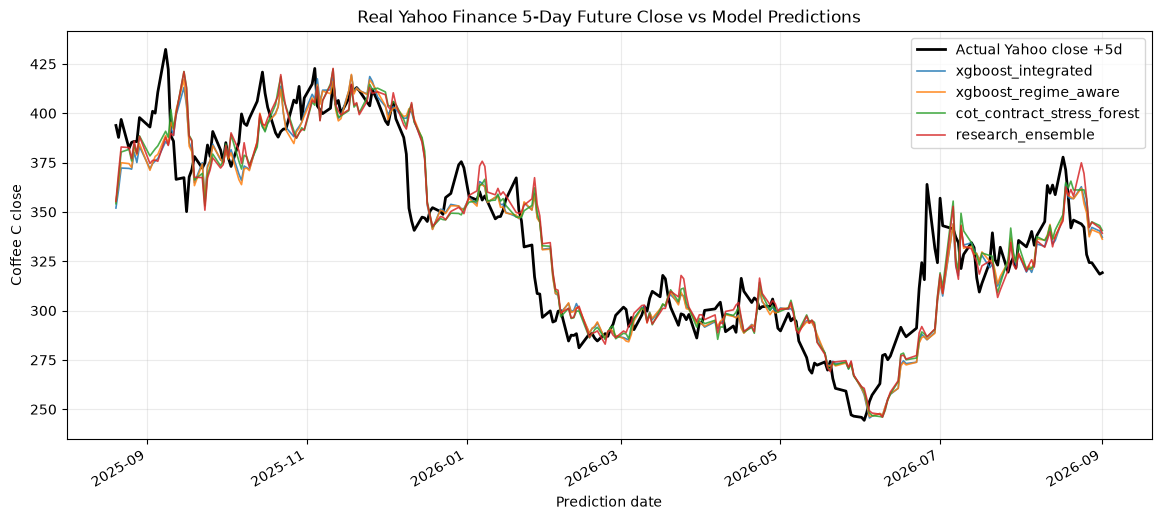

In [10]:
import matplotlib.pyplot as plt

plot_models = [m for m in ["xgboost_integrated", "xgboost_regime_aware", "cot_contract_stress_forest", "research_ensemble"] if f"{m}_predicted_close_5d" in predictions.columns]
plot_frame = predictions.tail(260).copy()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(plot_frame["Date"], plot_frame["target_close_5d"], label="Actual Yahoo close +5d", color="black", linewidth=2)
for model in plot_models:
    ax.plot(plot_frame["Date"], plot_frame[f"{model}_predicted_close_5d"], label=model, linewidth=1.2, alpha=0.85)
ax.set_title("Real Yahoo Finance 5-Day Future Close vs Model Predictions")
ax.set_xlabel("Prediction date")
ax.set_ylabel("Coffee C close")
ax.legend(loc="best")
ax.grid(True, alpha=0.25)
fig.autofmt_xdate()
plot_path = PLOTS_DIR / "research_paper_real_yahoo_close_comparison.png"
fig.savefig(plot_path, dpi=180, bbox_inches="tight")
print(f"Saved: {plot_path.relative_to(ROOT)}")
plt.show()

## 6. Visual Checks

Scripts/project/artifacts/plots/research_paper_model_comparison.png


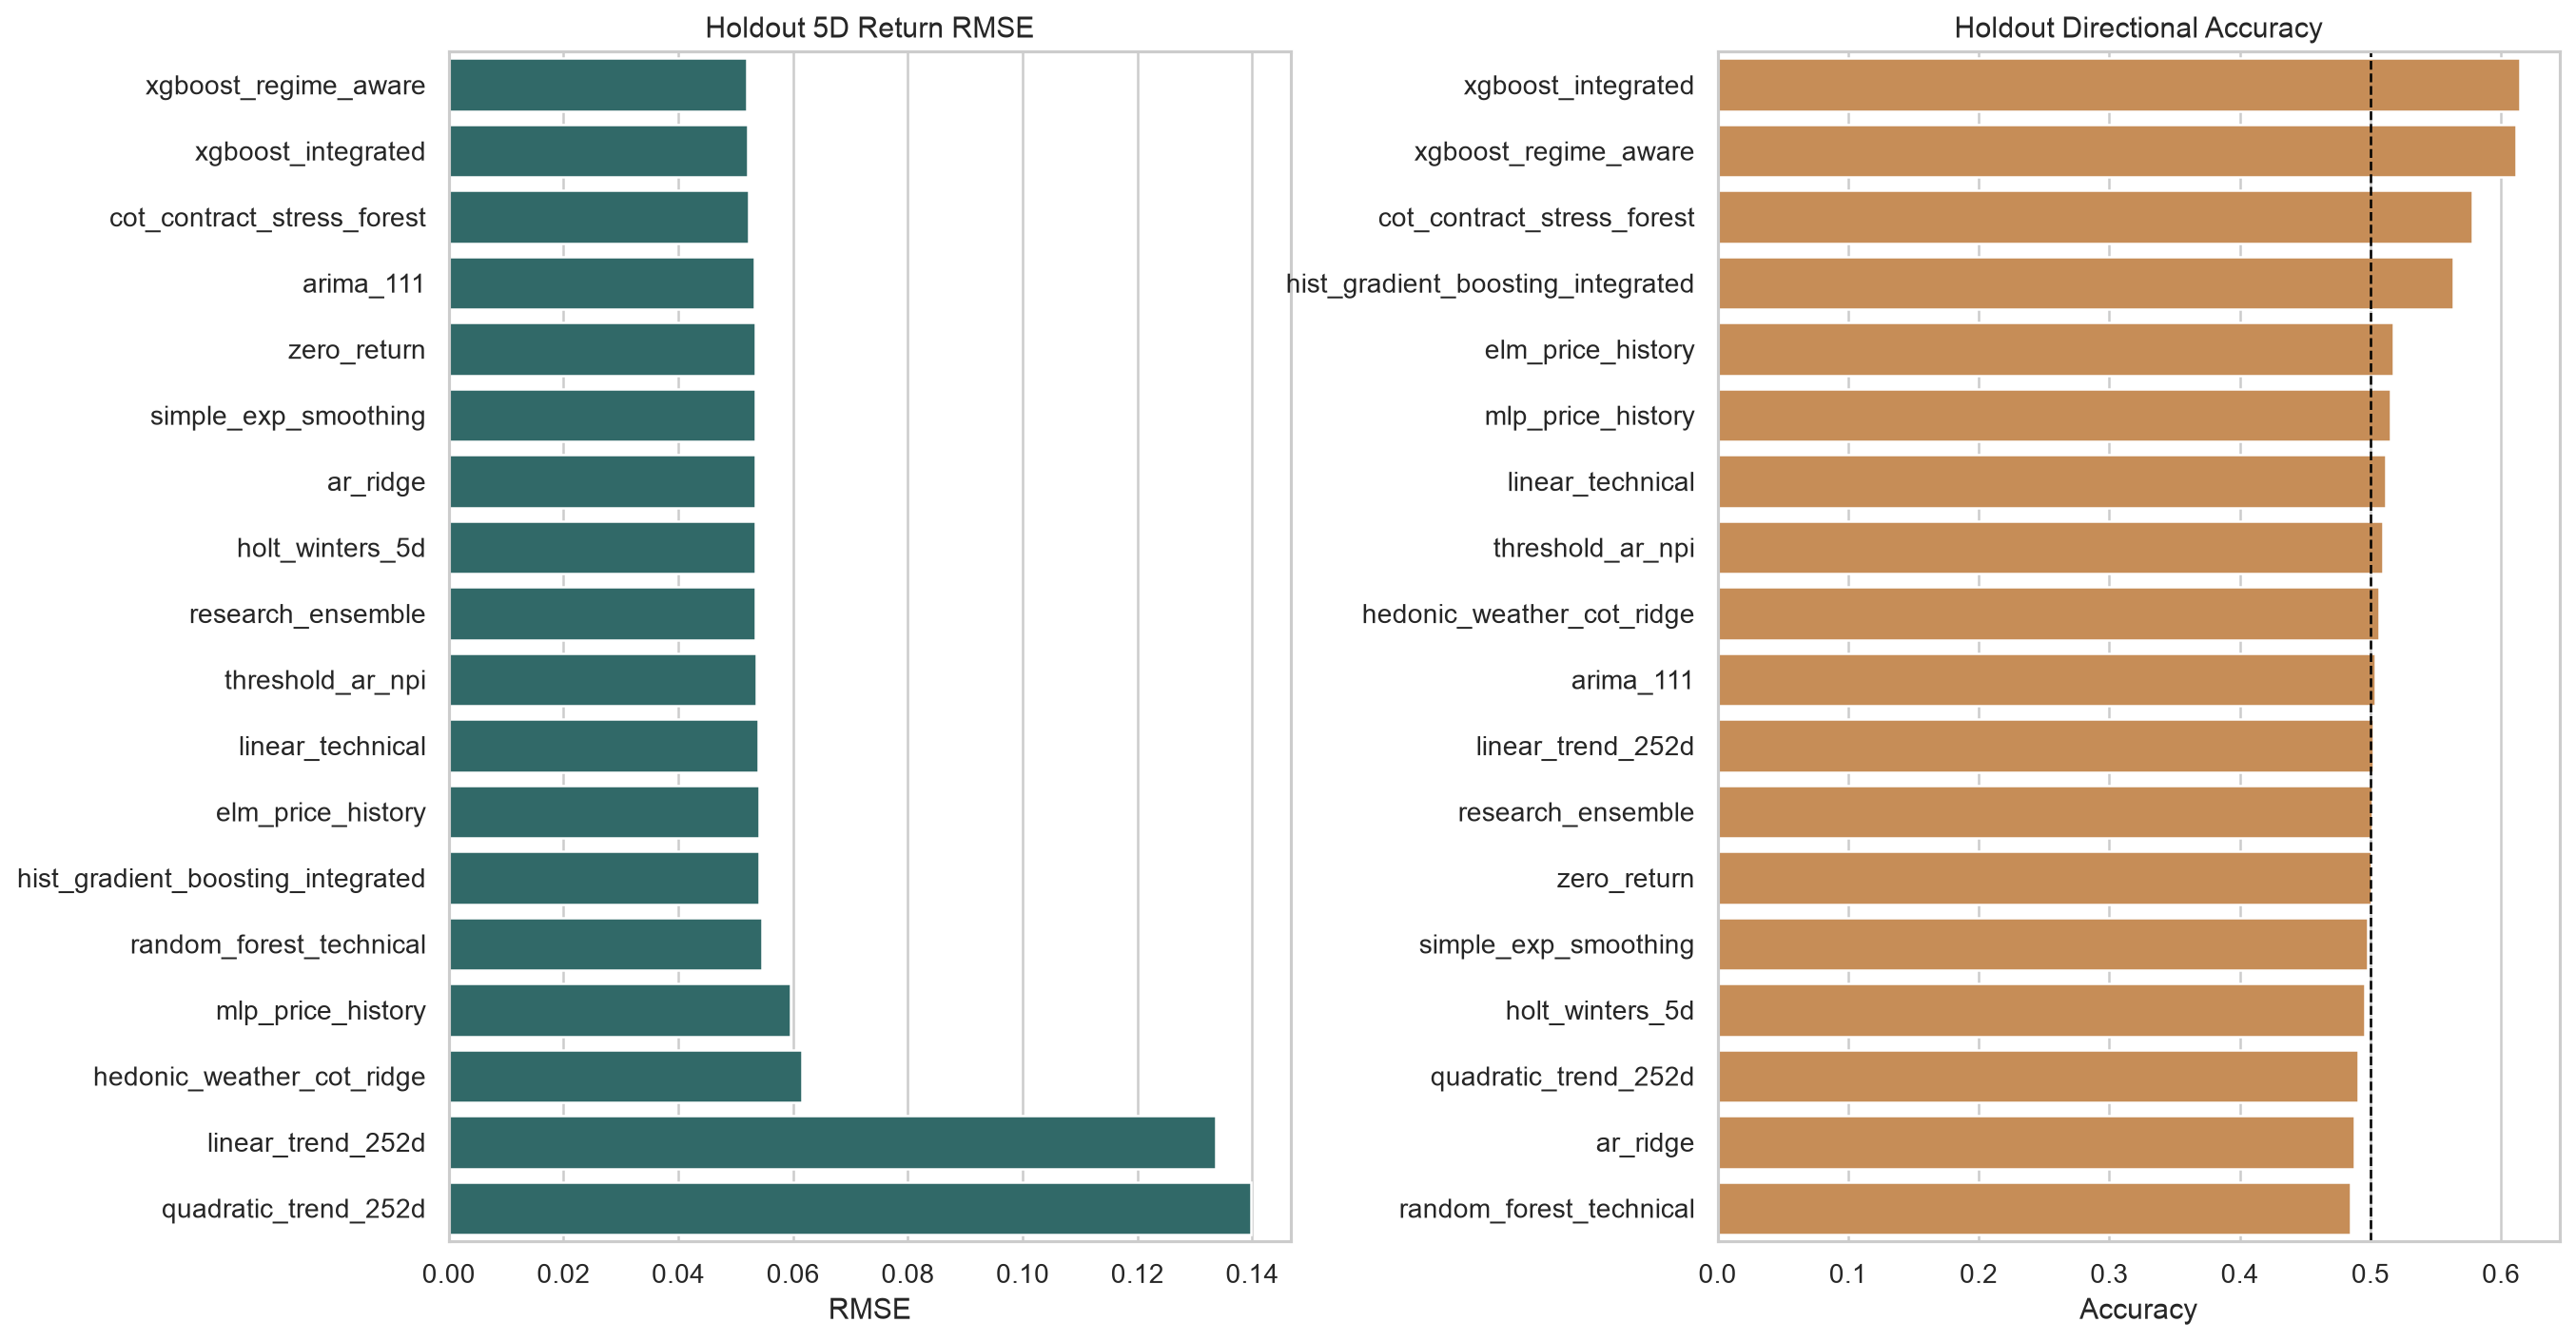

Scripts/project/artifacts/plots/research_paper_roc_curves.png


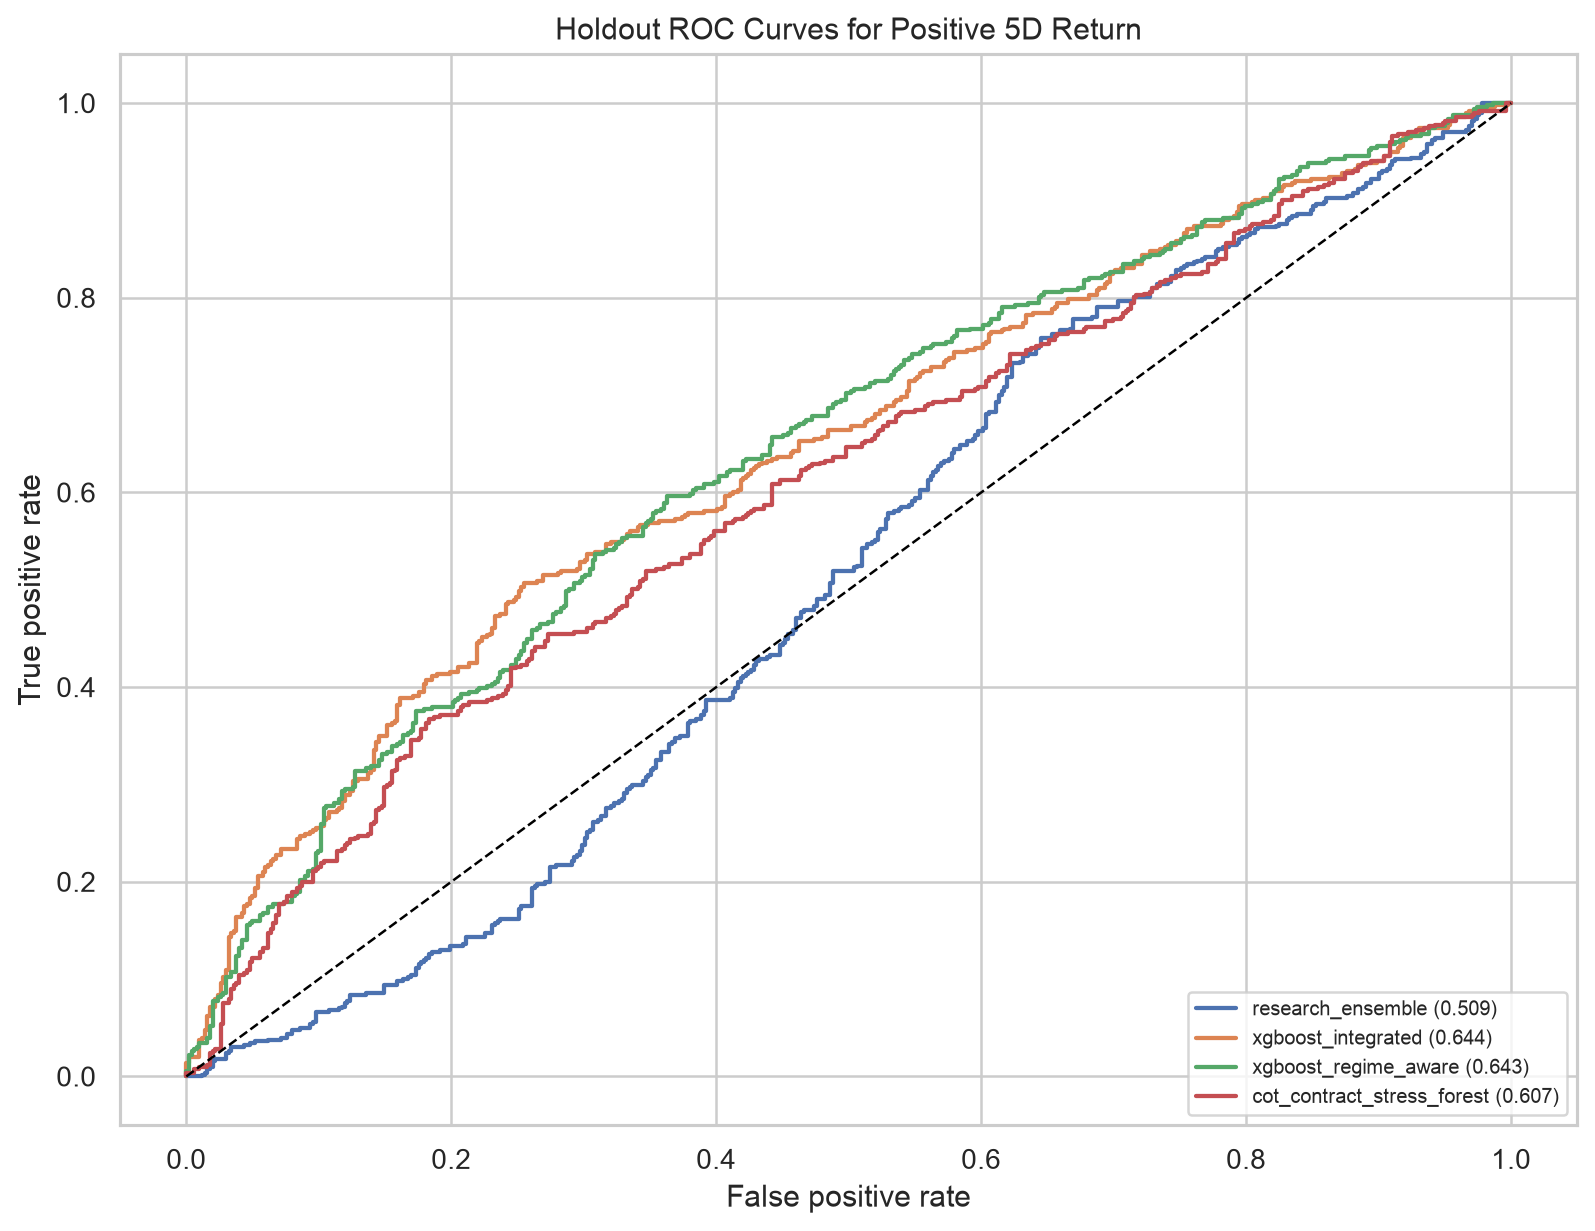

Scripts/project/artifacts/plots/research_paper_confusion_matrices.png


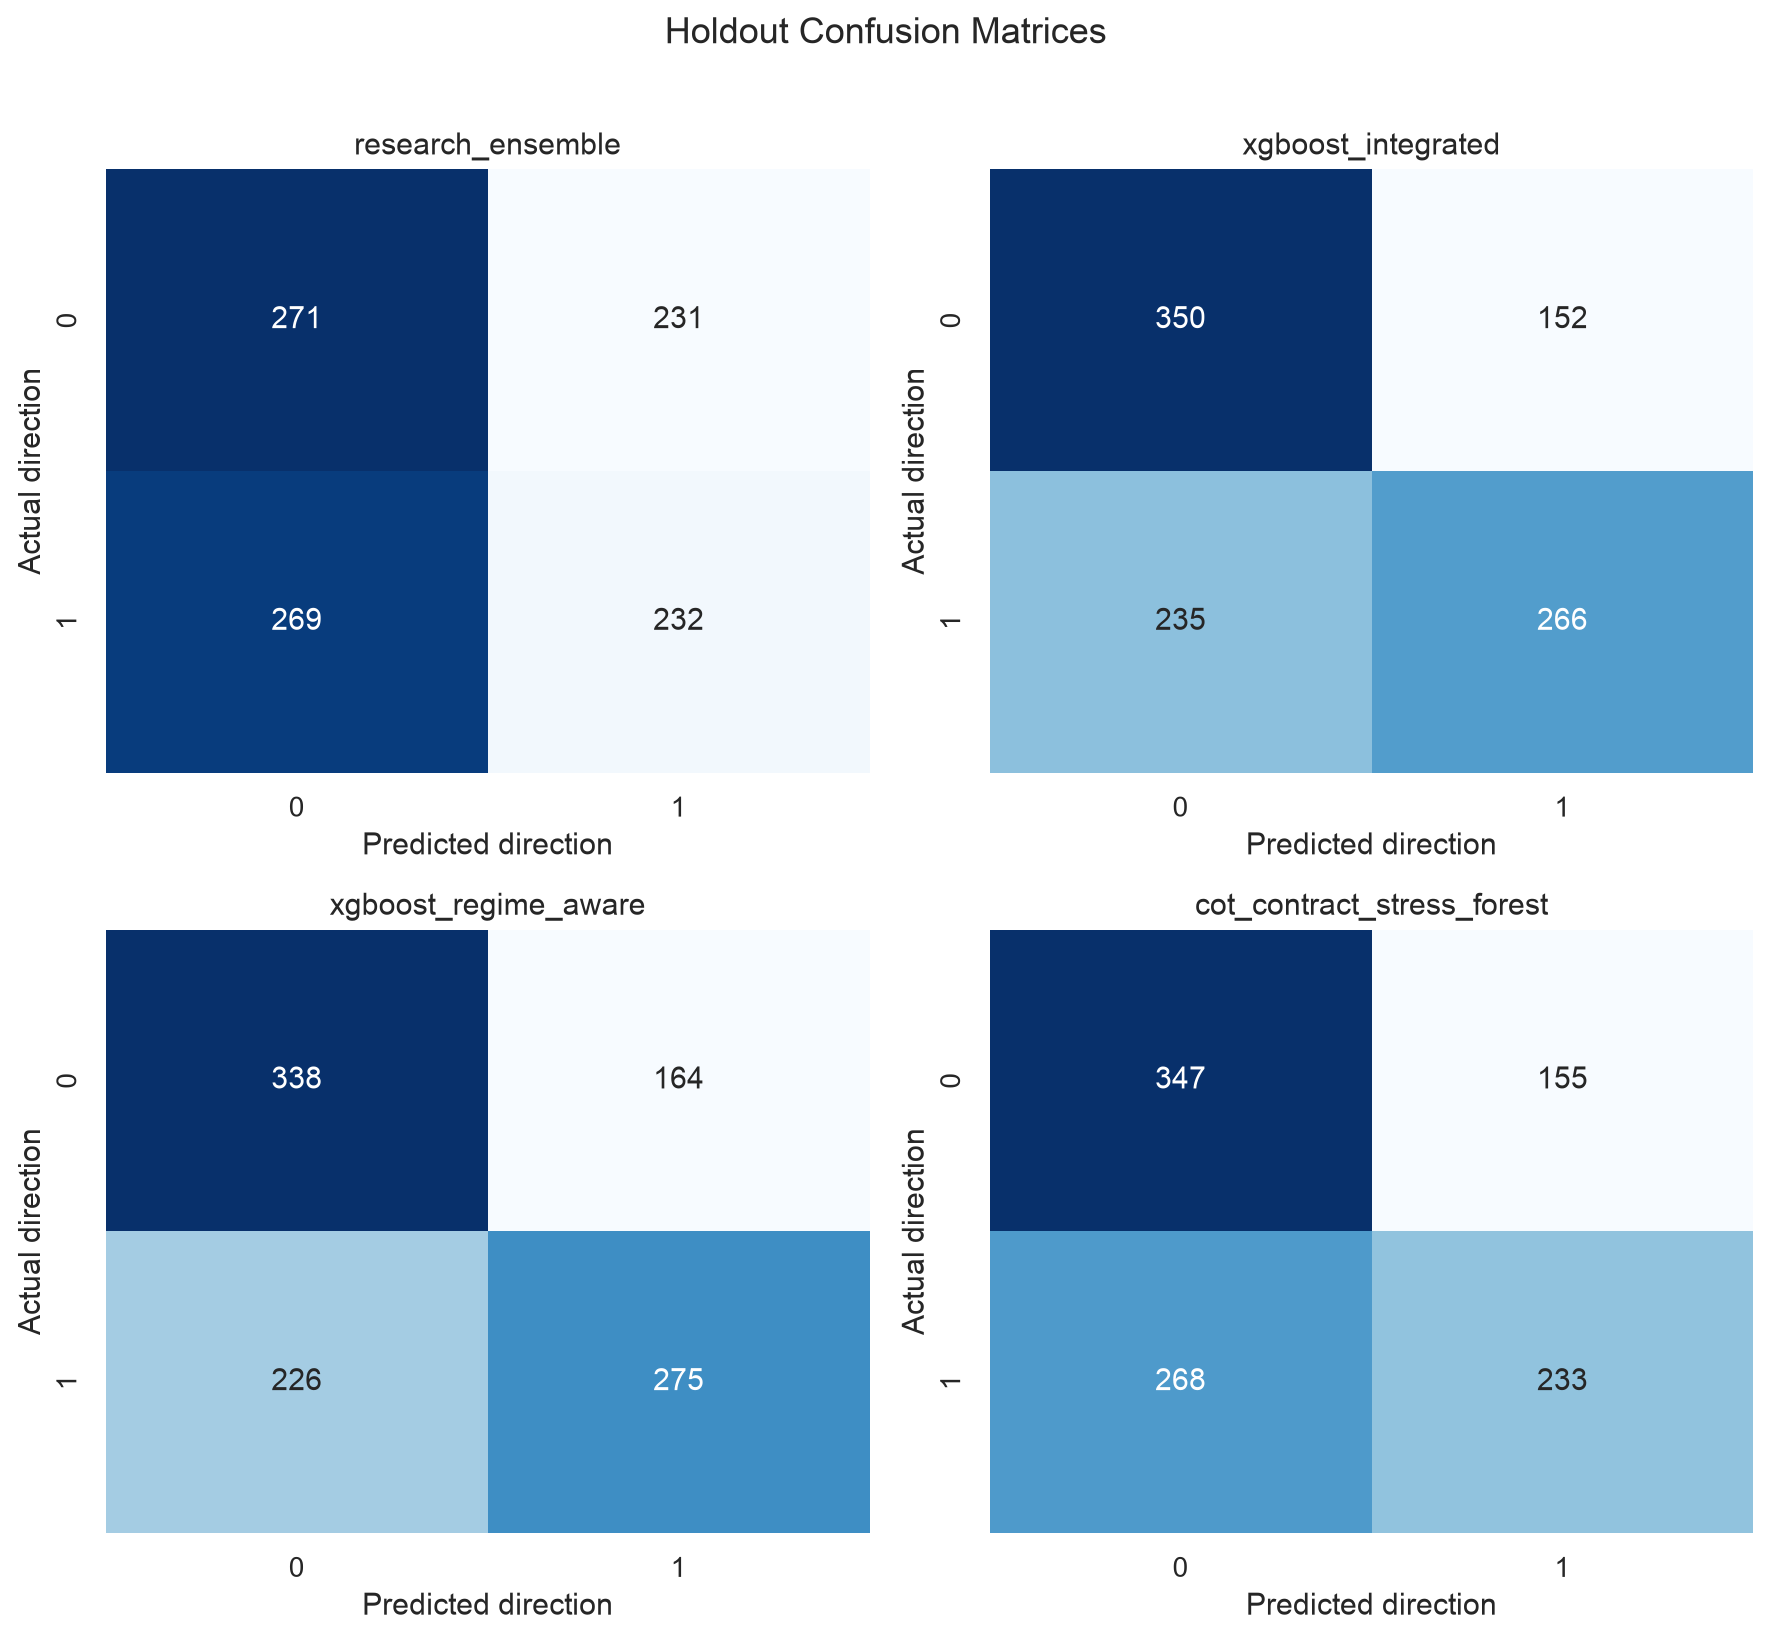

Scripts/project/artifacts/plots/research_paper_regime_direction_accuracy.png


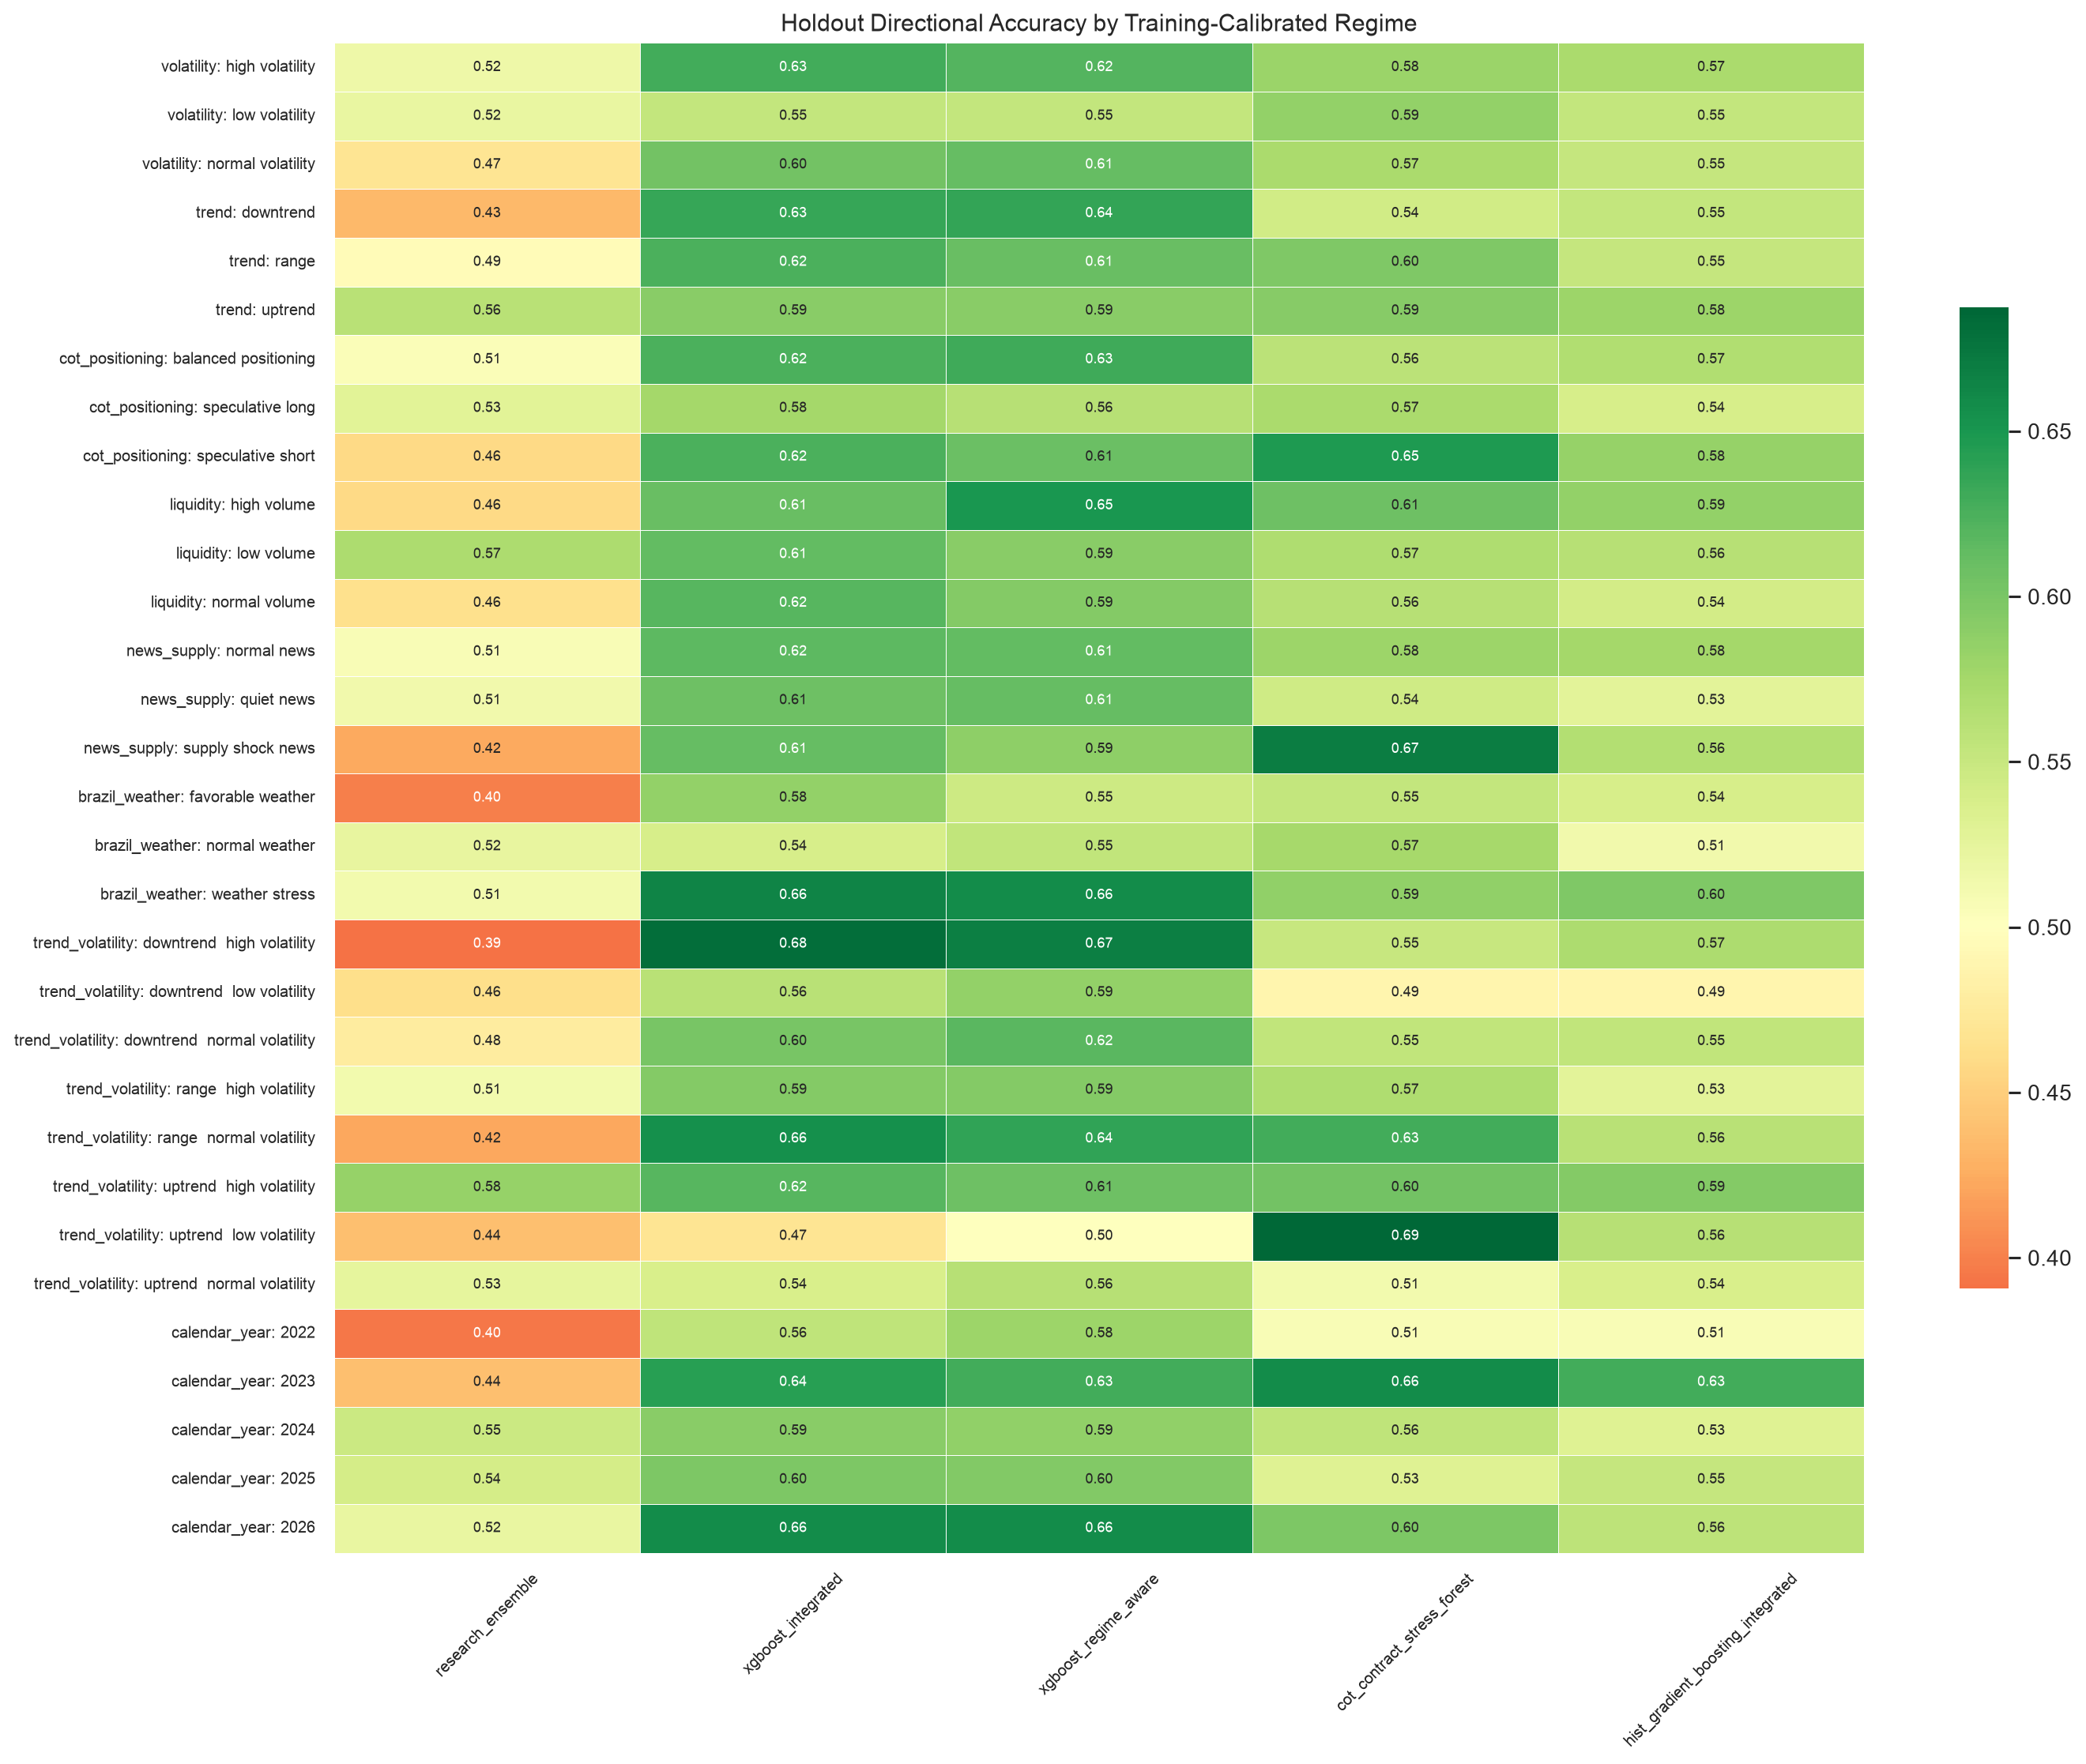

Scripts/project/artifacts/plots/research_paper_regime_rmse_improvement.png


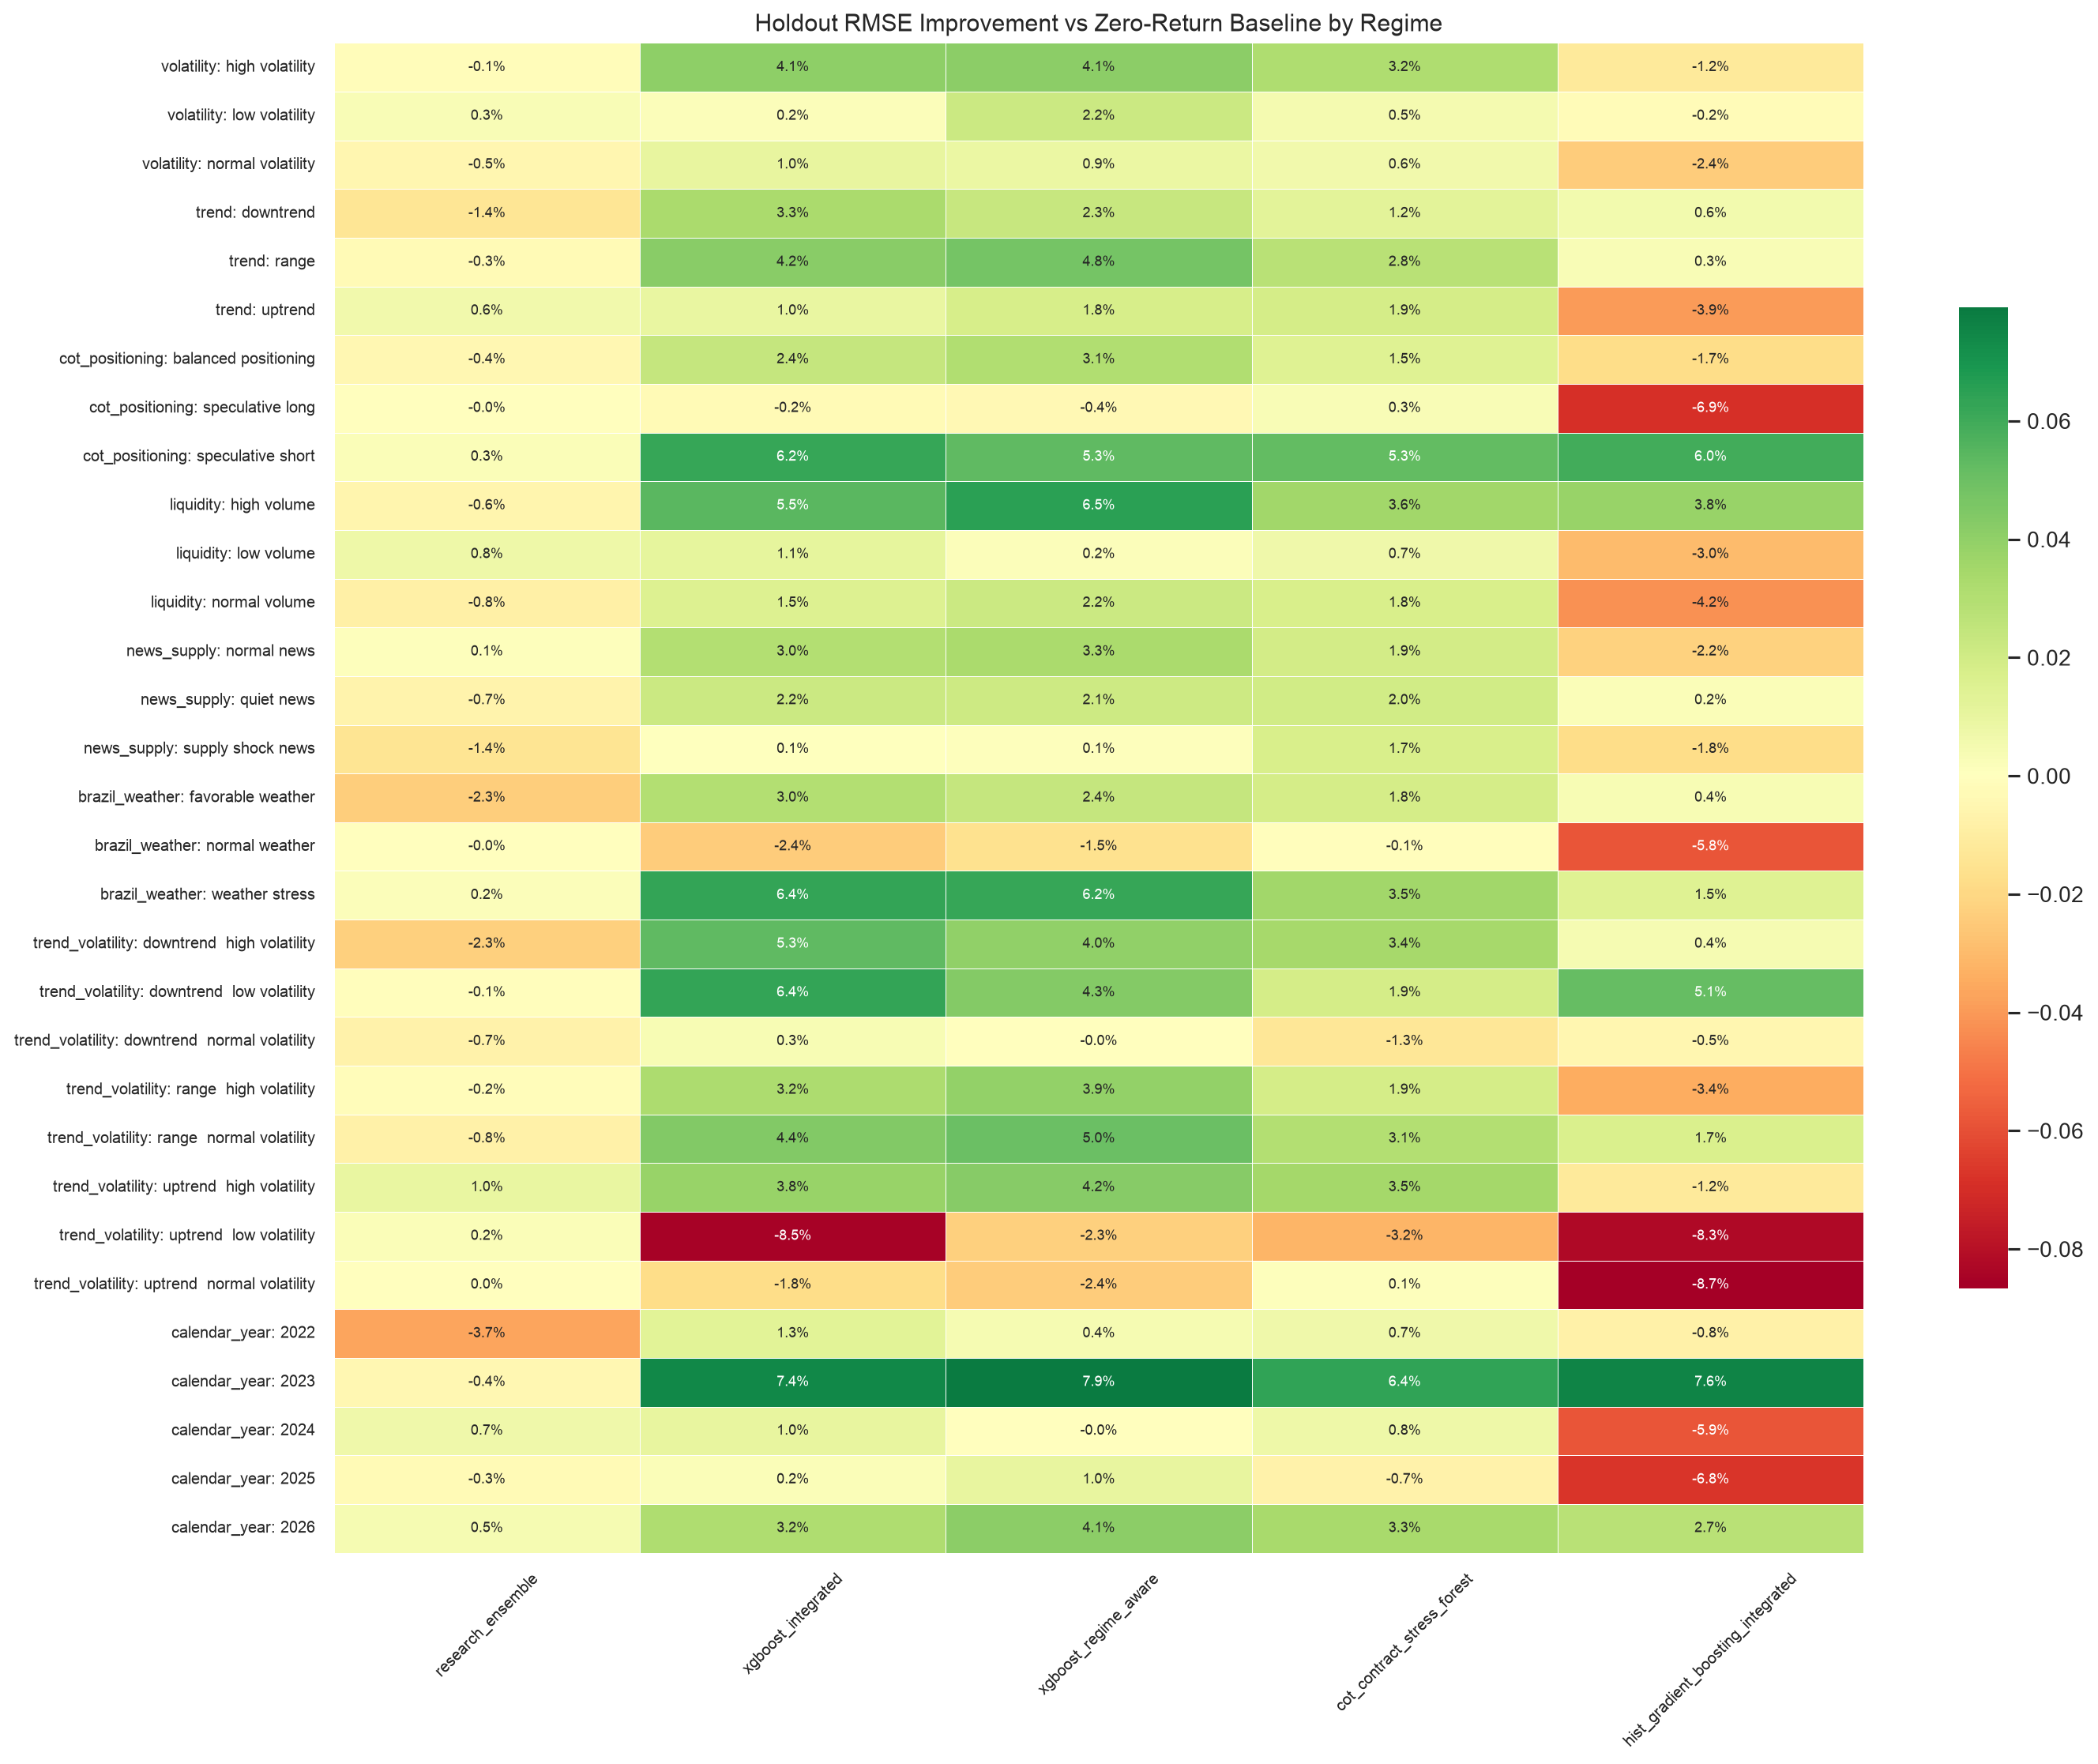

Scripts/project/artifacts/plots/research_paper_strategy_equity.png


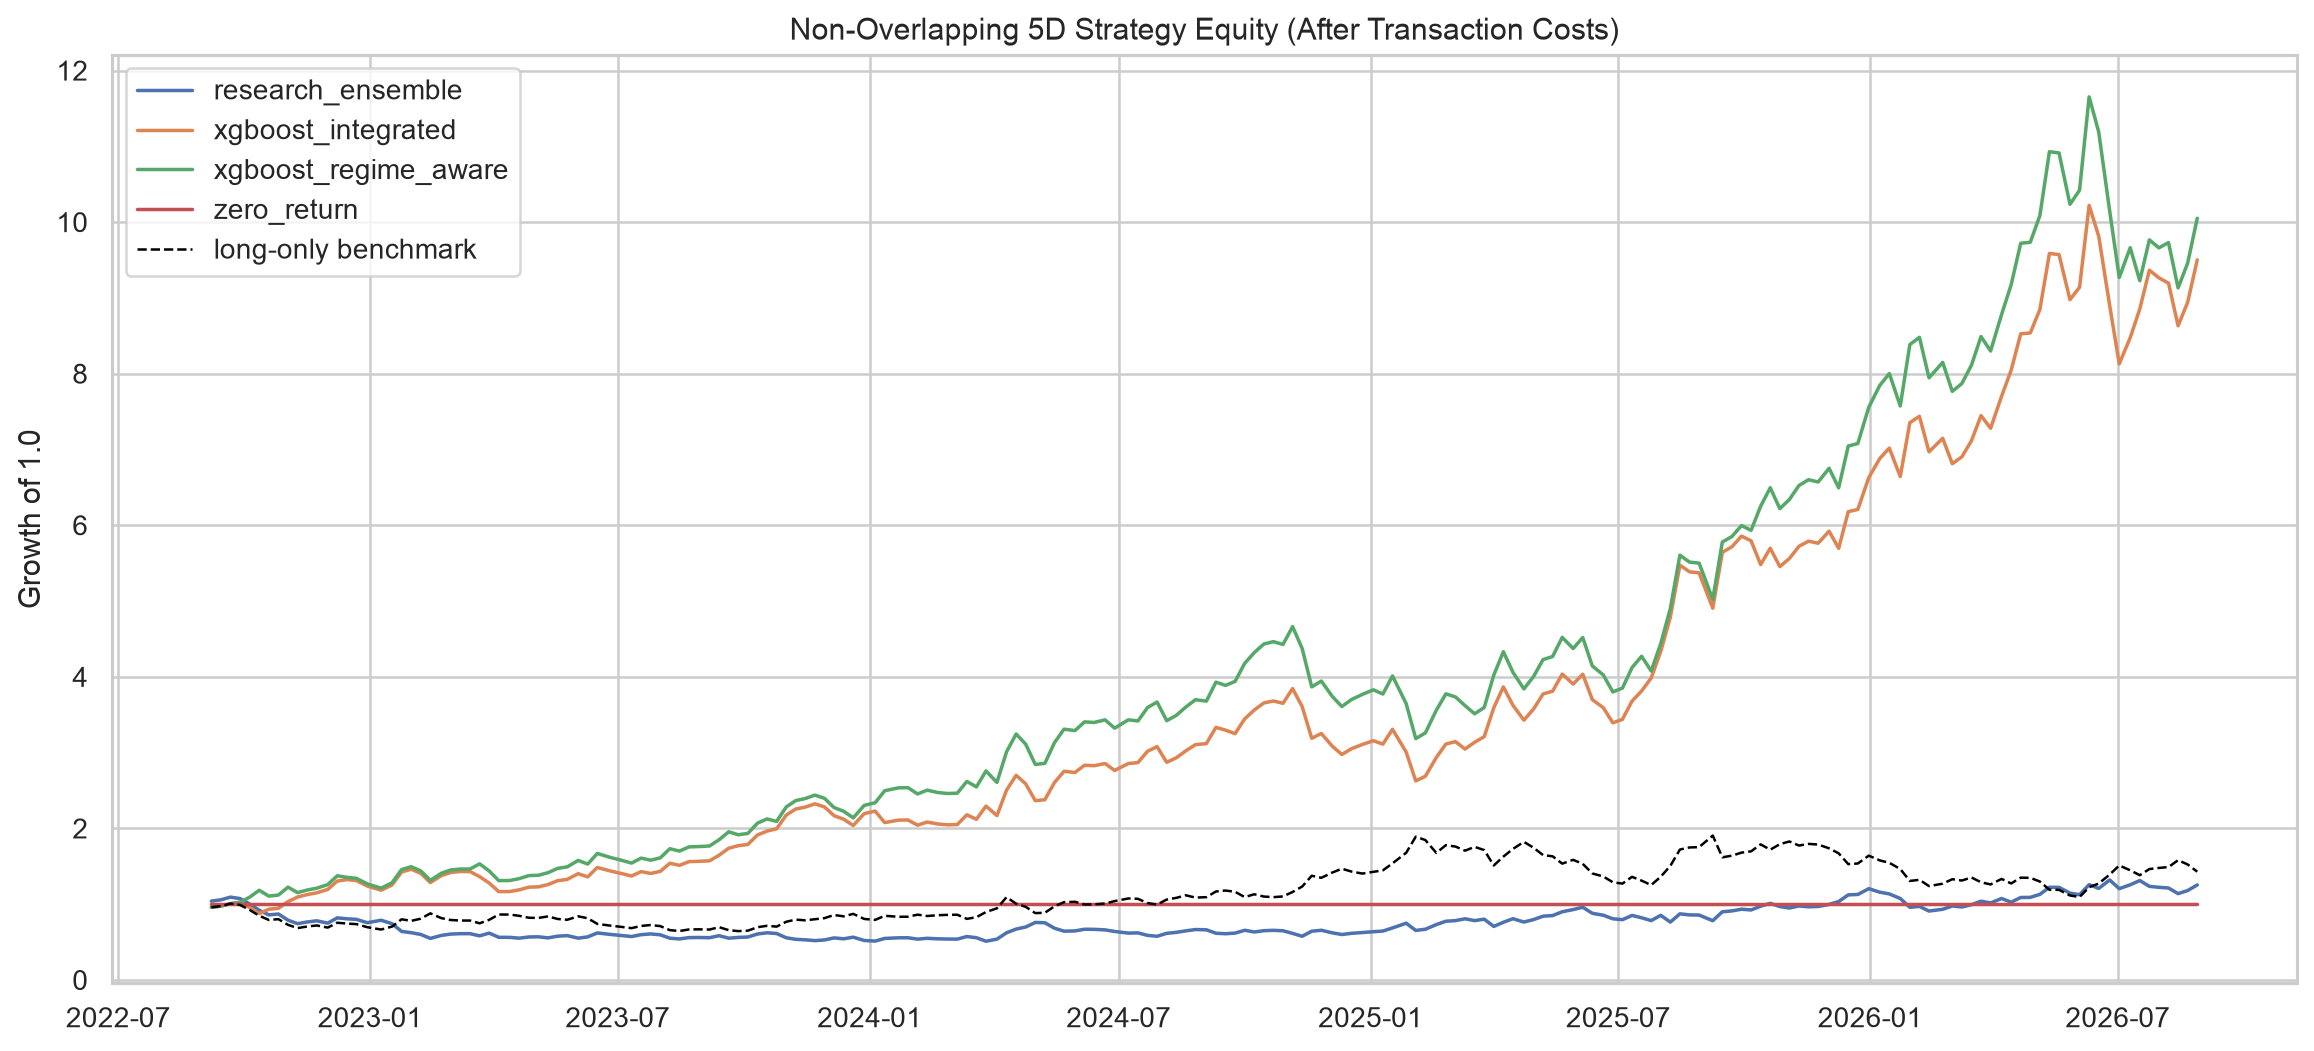

Scripts/project/artifacts/plots/research_paper_residual_diagnostics.png


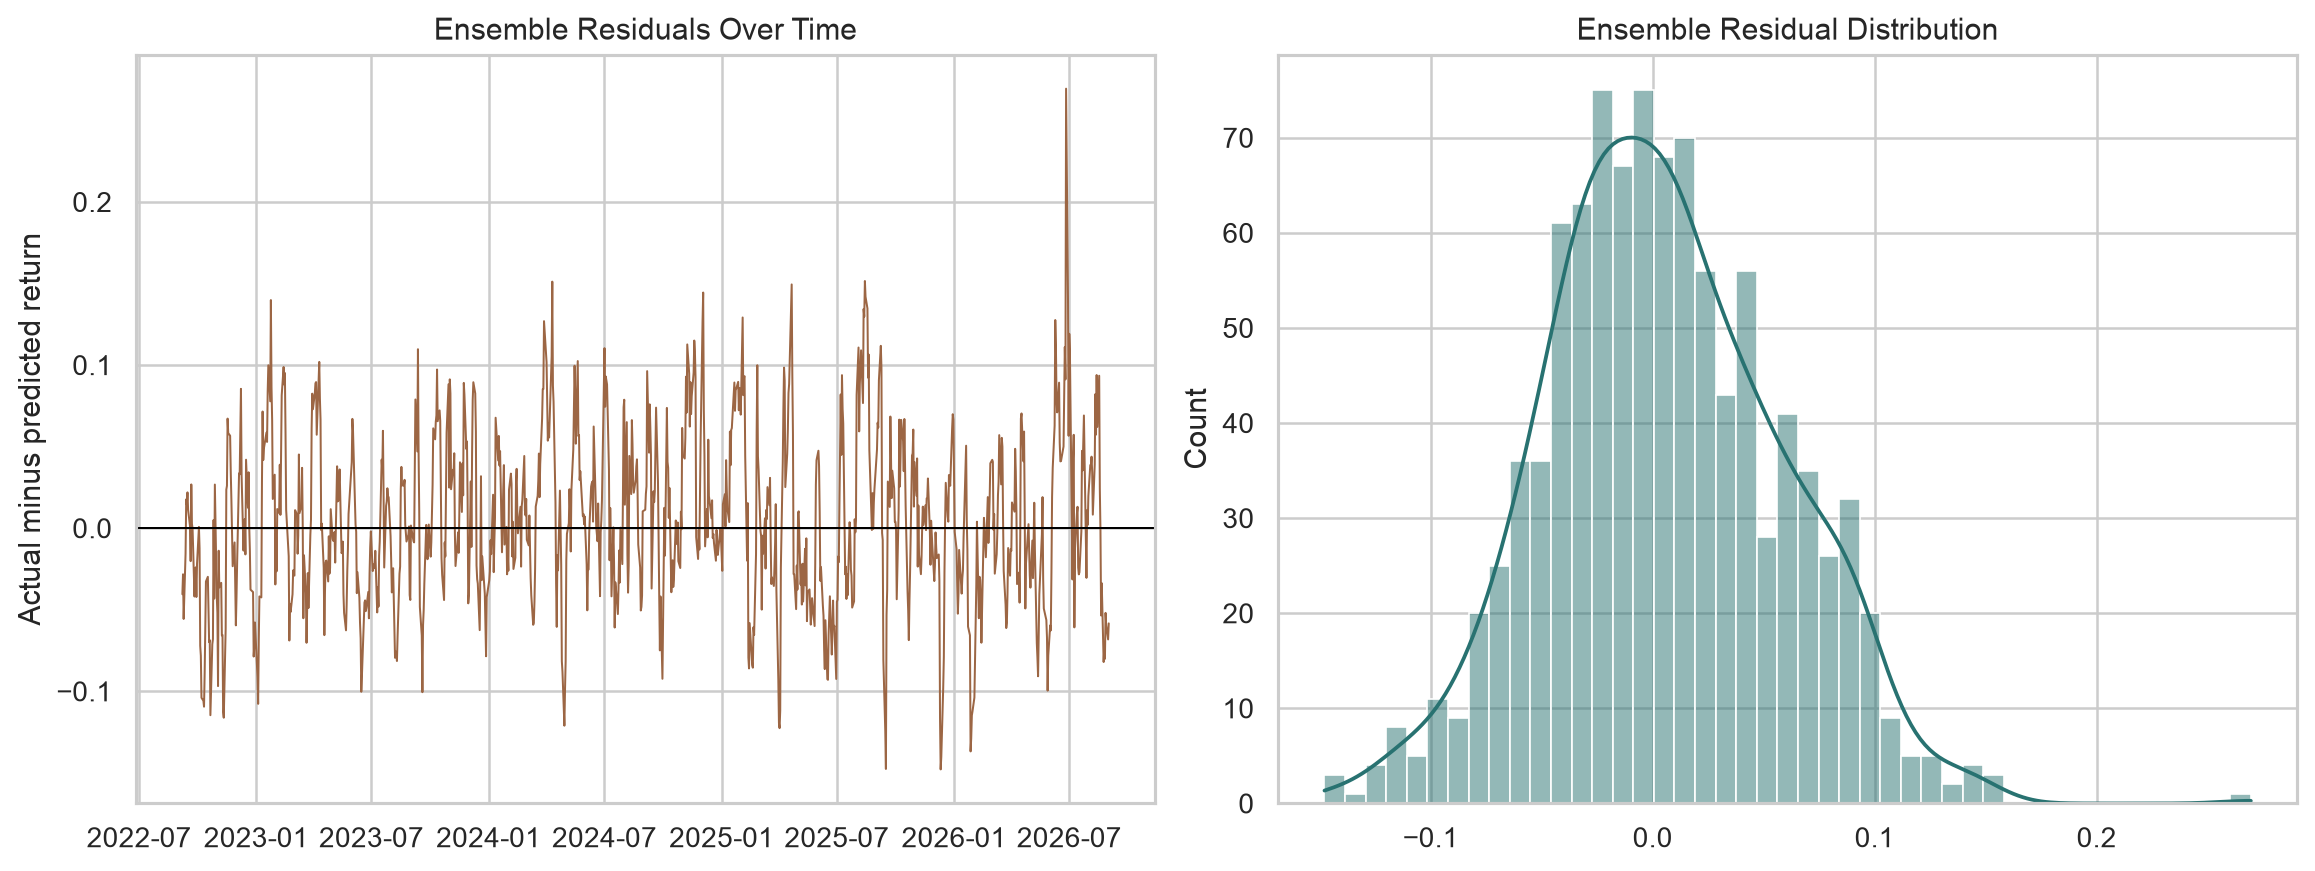

In [11]:
plot_files = [
    "research_paper_model_comparison.png",
    "research_paper_roc_curves.png",
    "research_paper_confusion_matrices.png",
    "research_paper_regime_direction_accuracy.png",
    "research_paper_regime_rmse_improvement.png",
    "research_paper_strategy_equity.png",
    "research_paper_residual_diagnostics.png",
]
for name in plot_files:
    path = PLOTS_DIR / name
    if path.exists():
        print(path.relative_to(ROOT))
        display(Image(filename=str(path)))
    else:
        print(f"Missing: {path.relative_to(ROOT)}")

## 7. Artifact Check

In [12]:
artifact_paths = {
    "model": MODELS_DIR / "research_paper_ensemble.joblib",
    "metrics": metrics_path,
    "comparison": comparison_path,
    "cv_summary": cv_summary_path,
    "holdout_predictions": OUTPUTS_DIR / "research_paper_model_holdout_predictions.csv",
    "confusion_matrices": OUTPUTS_DIR / "research_paper_model_confusion_matrices.csv",
    "regime_summary": OUTPUTS_DIR / "research_paper_regime_summary.json",
}
{k: {"exists": p.exists(), "path": str(p.relative_to(ROOT)), "size_bytes": p.stat().st_size if p.exists() else None} for k, p in artifact_paths.items()}

{'model': {'exists': True,
  'path': 'Scripts/project/artifacts/models/research_paper_ensemble.joblib',
  'size_bytes': 5082015},
 'metrics': {'exists': True,
  'path': 'Scripts/project/artifacts/outputs/research_paper_ensemble_metrics.json',
  'size_bytes': 196135},
 'comparison': {'exists': True,
  'path': 'Scripts/project/artifacts/outputs/research_paper_model_comparison.csv',
  'size_bytes': 29718},
 'cv_summary': {'exists': True,
  'path': 'Scripts/project/artifacts/outputs/research_paper_model_cv_summary.csv',
  'size_bytes': 4547},
 'holdout_predictions': {'exists': True,
  'path': 'Scripts/project/artifacts/outputs/research_paper_model_holdout_predictions.csv',
  'size_bytes': 809246},
 'confusion_matrices': {'exists': True,
  'path': 'Scripts/project/artifacts/outputs/research_paper_model_confusion_matrices.csv',
  'size_bytes': 642},
 'regime_summary': {'exists': True,
  'path': 'Scripts/project/artifacts/outputs/research_paper_regime_summary.json',
  'size_bytes': 27933}}

## Prediction Console

Interactive widget tabs for predicting **Arabica coffee futures returns**. Use the **Inputs** tab, press **Run Prediction**, then inspect the prediction table, model dashboard, and processing context in the other tabs.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

MODEL_BUNDLE_PATH = ROOT / "Scripts" / "project" / "artifacts" / "models" / "research_paper_ensemble.joblib"
READY_DATA_PATH = ROOT / "data" / "centralData" / "arabica_ml_model_ready.csv"
EVENTS_DATA_PATH = ROOT / "data" / "events" / "gdelt_coffee_events_2000_2026_filtered_scored.csv"
WEATHER_CACHE_PATH = ROOT / "data" / "weather" / "open_meteo_coffee_regions_daily.csv"
PREDICTION_OUTPUT_PATH = OUTPUTS_DIR / "latest_research_paper_return_predictions.csv"
PREDICTION_PLOT_PATH = PLOTS_DIR / "latest_research_paper_return_prediction_console.png"
MODEL_METRICS_PATH = OUTPUTS_DIR / "research_paper_model_comparison.csv"
HOLDOUT_PREDICTIONS_PATH = OUTPUTS_DIR / "research_paper_model_holdout_predictions.csv"

# Static options make the widget render immediately. The model bundle is loaded only after Run Prediction.
MODEL_OPTIONS = [
    "all",
    "xgboost_integrated",
    "xgboost_regime_aware",
    "cot_contract_stress_forest",
    "hist_gradient_boosting_integrated",
    "random_forest_technical",
    "hedonic_weather_cot_ridge",
    "research_ensemble",
]

model_dropdown = widgets.Dropdown(options=MODEL_OPTIONS, value="xgboost_integrated", description="Model:", layout=widgets.Layout(width="440px"))
latest_rows_slider = widgets.IntSlider(value=30, min=5, max=180, step=5, description="Rows:", continuous_update=False, layout=widgets.Layout(width="440px"))
future_dates_slider = widgets.IntSlider(value=5, min=0, max=30, step=1, description="Future dates:", continuous_update=False, layout=widgets.Layout(width="440px"))
drift_threshold = widgets.FloatSlider(value=0.005, min=0.0, max=0.03, step=0.001, readout_format=".3f", description="Threshold:", continuous_update=False, layout=widgets.Layout(width="440px"))
use_events_check = widgets.Checkbox(value=True, description="Use local GDELT/news events")
refresh_weather_check = widgets.Checkbox(value=False, description="Fetch latest cached weather first")
rebuild_data_check = widgets.Checkbox(value=False, description="Rebuild model-ready data first")
run_button = widgets.Button(description="Run Prediction", button_style="primary", icon="play")
status_html = widgets.HTML(value="Ready. Press <b>Run Prediction</b>.")

inputs_out = widgets.Output()
prediction_out = widgets.Output()
plot_out = widgets.Output()
context_out = widgets.Output()

def display_path(path):
    try:
        return path.relative_to(ROOT)
    except ValueError:
        return path

def _lazy_prediction_imports():
    import sys
    import joblib
    import numpy as np
    import matplotlib.pyplot as plt

    src_path = ROOT / "Scripts" / "project" / "src"
    scripts_path = ROOT / "Scripts" / "project" / "scripts"
    for path in [src_path, scripts_path]:
        if str(path) not in sys.path:
            sys.path.append(str(path))

    from train_research_paper_ensemble import (  # noqa: E402
        add_local_regime_features,
        add_paper_positioning_features,
        build_safe_event_features,
    )
    return joblib, np, plt, add_local_regime_features, add_paper_positioning_features, build_safe_event_features

def make_prediction(_=None):
    run_button.disabled = True
    status_html.value = "<b>Running...</b> loading model and local features."
    prediction_out.clear_output()
    plot_out.clear_output()
    context_out.clear_output()
    try:
        joblib, np, plt, add_local_regime_features, add_paper_positioning_features, build_safe_event_features = _lazy_prediction_imports()

        if refresh_weather_check.value:
            status_html.value = "<b>Refreshing weather...</b>"
            run_script("Scripts/project/scripts/refresh_weather_cache.py", "--force-all")
        if rebuild_data_check.value:
            status_html.value = "<b>Rebuilding model-ready data...</b>"
            run_script("Scripts/project/scripts/fill_cot_forward_daily.py")
            run_script("Scripts/project/scripts/prepare_ml_dataset.py")

        status_html.value = "<b>Loading model bundle...</b>"
        bundle = joblib.load(MODEL_BUNDLE_PATH)
        model_specs_by_name = {spec["name"]: spec for spec in bundle["model_specs"]}
        production_models = bundle["production"]["sklearn_models"]
        available_model_names = list(production_models)
        if "research_ensemble" not in available_model_names:
            available_model_names.append("research_ensemble")

        def predict_model_returns(model_name, rows):
            if model_name == "research_ensemble":
                member_predictions = []
                member_weights = []
                for member in bundle.get("ensemble_members", []):
                    if member not in production_models or member not in model_specs_by_name:
                        continue
                    member_predictions.append(predict_model_returns(member, rows))
                    member_weights.append(float(bundle.get("ensemble_weights", {}).get(member, 0.0)))
                if not member_predictions:
                    raise ValueError("No available production ensemble members found.")
                weights = np.asarray(member_weights, dtype=float)
                weights = weights / weights.sum() if weights.sum() else np.full_like(weights, 1.0 / len(weights))
                return np.average(np.vstack(member_predictions), axis=0, weights=weights)

            if model_name not in production_models:
                raise ValueError(f"Model not found in production bundle: {model_name}")
            spec = model_specs_by_name[model_name]
            X = rows.reindex(columns=spec["features"]).replace([np.inf, -np.inf], np.nan)
            return production_models[model_name].predict(X)

        status_html.value = "<b>Building feature frame...</b>"
        prediction_frame = pd.read_csv(READY_DATA_PATH, parse_dates=["Date"], low_memory=False)
        prediction_frame = add_paper_positioning_features(prediction_frame)
        if use_events_check.value and EVENTS_DATA_PATH.exists():
            event_features, event_audit = build_safe_event_features(
                EVENTS_DATA_PATH,
                start_date=prediction_frame["Date"].min(),
                end_date=prediction_frame["Date"].max(),
            )
            prediction_frame = prediction_frame.merge(event_features, on="Date", how="left", validate="one_to_one")
        else:
            event_audit = {"enabled": False, "reason": "local events disabled or missing"}
        prediction_frame = add_local_regime_features(prediction_frame)
        horizon = int(bundle.get("horizon", 5) or 5)
        historical_rows = prediction_frame.sort_values("Date").tail(latest_rows_slider.value).copy().reset_index(drop=True)
        historical_rows["row_type"] = "historical"
        historical_rows["feature_basis_date"] = historical_rows["Date"]

        future_days = int(future_dates_slider.value)
        if future_days:
            future_dates = pd.bdate_range(historical_rows["Date"].max() + pd.offsets.BDay(1), periods=future_days)
            future_rows = pd.concat([historical_rows.tail(1)] * future_days, ignore_index=True)
            future_rows["Date"] = future_dates
            future_rows["row_type"] = "future_scenario"
            future_rows["feature_basis_date"] = historical_rows["Date"].max()
            latest_rows = pd.concat([historical_rows, future_rows], ignore_index=True)
        else:
            latest_rows = historical_rows

        selected_models = available_model_names if model_dropdown.value == "all" else [model_dropdown.value]
        threshold = float(drift_threshold.value)
        metrics_frame = pd.read_csv(MODEL_METRICS_PATH) if MODEL_METRICS_PATH.exists() else pd.DataFrame()
        holdout_frame = pd.read_csv(HOLDOUT_PREDICTIONS_PATH) if HOLDOUT_PREDICTIONS_PATH.exists() else pd.DataFrame()
        prediction_output = latest_rows[["Date", "feature_basis_date", "row_type", "Close"]].copy()
        prediction_output["forecast_target_date"] = prediction_output["Date"].map(lambda date: date + pd.offsets.BDay(horizon))
        summary_rows = []

        status_html.value = "<b>Scoring...</b>"
        for model_name in selected_models:
            pred_return = predict_model_returns(model_name, latest_rows)
            pred_close = latest_rows["Close"].to_numpy(dtype=float) * (1.0 + pred_return)
            signal = np.where(pred_return > threshold, "positive", np.where(pred_return < -threshold, "negative", "neutral"))
            prediction_output[f"{model_name}_predicted_return_5d"] = pred_return
            prediction_output[f"{model_name}_predicted_close_5d"] = pred_close
            prediction_output[f"{model_name}_signal"] = signal

            residual_low = np.nan
            residual_high = np.nan
            holdout_pred_col = f"{model_name}_predicted_return_5d"
            if {"target_return_5d", holdout_pred_col}.issubset(holdout_frame.columns):
                residuals = (
                    pd.to_numeric(holdout_frame["target_return_5d"], errors="coerce")
                    - pd.to_numeric(holdout_frame[holdout_pred_col], errors="coerce")
                ).dropna()
                if len(residuals) >= 20:
                    residual_low, residual_high = residuals.quantile([0.05, 0.95]).tolist()

            return_low = pred_return + residual_low
            return_high = pred_return + residual_high
            prediction_output[f"{model_name}_return_low_90"] = return_low
            prediction_output[f"{model_name}_return_high_90"] = return_high
            prediction_output[f"{model_name}_close_low_90"] = latest_rows["Close"].to_numpy(dtype=float) * (1.0 + return_low)
            prediction_output[f"{model_name}_close_high_90"] = latest_rows["Close"].to_numpy(dtype=float) * (1.0 + return_high)

            metric_match = pd.DataFrame()
            if {"model", "phase"}.issubset(metrics_frame.columns):
                metric_match = metrics_frame.loc[
                    metrics_frame["model"].eq(model_name) & metrics_frame["phase"].eq("test")
                ]
            metric_row = metric_match.iloc[-1] if len(metric_match) else pd.Series(dtype=float)
            summary_rows.append({
                "model": model_name,
                "latest_forecast_base_date": prediction_output["Date"].iloc[-1].date().isoformat(),
                "latest_forecast_target_date": prediction_output["forecast_target_date"].iloc[-1].date().isoformat(),
                "latest_close": float(prediction_output["Close"].iloc[-1]),
                "predicted_return_5d": float(pred_return[-1]),
                "predicted_close_5d": float(pred_close[-1]),
                "signal": signal[-1],
                "return_low_90": float(return_low[-1]),
                "return_high_90": float(return_high[-1]),
                "test_directional_accuracy": float(metric_row.get("directional_accuracy", np.nan)),
                "test_strategy_sharpe": float(metric_row.get("strategy_sharpe", np.nan)),
                "test_rmse": float(metric_row.get("rmse", np.nan)),
                "mean_predicted_return_over_window": float(np.mean(pred_return)),
                "positive_days": int((pred_return > threshold).sum()),
                "negative_days": int((pred_return < -threshold).sum()),
                "neutral_days": int((np.abs(pred_return) <= threshold).sum()),
            })

        prediction_output.to_csv(PREDICTION_OUTPUT_PATH, index=False)
        summary = pd.DataFrame(summary_rows).sort_values("predicted_return_5d", ascending=False)

        with prediction_out:
            clear_output(wait=True)
            display(summary)
            display(prediction_output.tail(20))
            print(f"Saved: {display_path(PREDICTION_OUTPUT_PATH)}")

        with plot_out:
            clear_output(wait=True)
            import matplotlib.dates as mdates
            from matplotlib.ticker import PercentFormatter

            BG = "#0b1114"
            PANEL = "#141d22"
            BORDER = "#52616a"
            FG = "#eef3f5"
            MUTED = "#9fb0b8"
            GRID = "#33434b"
            GREEN = "#5ecb78"
            RED = "#f0645a"
            AMBER = "#e5b94f"
            CYAN = "#4eb7c5"
            BLUE = "#6d8fe8"

            def style_panel(axis, title):
                axis.set_facecolor(PANEL)
                for spine in axis.spines.values():
                    spine.set_color(BORDER)
                    spine.set_linewidth(1.0)
                axis.tick_params(colors=MUTED, labelsize=9)
                axis.xaxis.label.set_color(MUTED)
                axis.yaxis.label.set_color(MUTED)
                axis.set_title(title, color=FG, fontsize=11, fontweight="bold", pad=10, loc="left")
                axis.grid(True, color=GRID, alpha=0.55, linewidth=0.7)
                axis.set_axisbelow(True)

            def style_stat(axis, title, value, subtitle, value_color=FG):
                axis.set_facecolor(PANEL)
                for spine in axis.spines.values():
                    spine.set_color(BORDER)
                    spine.set_linewidth(1.0)
                axis.set_xticks([])
                axis.set_yticks([])
                axis.set_xlim(0, 1)
                axis.set_ylim(0, 1)
                axis.text(0.05, 0.78, title, color=MUTED, fontsize=10, va="center")
                axis.text(0.05, 0.45, value, color=value_color, fontsize=25, fontweight="bold", va="center")
                axis.text(0.05, 0.14, subtitle, color=MUTED, fontsize=9, va="center")

            def row_number(row, column):
                value = pd.to_numeric(pd.Series([row.get(column, np.nan)]), errors="coerce").iloc[0]
                return float(value) if pd.notna(value) else np.nan

            dashboard_model = (
                "xgboost_integrated"
                if model_dropdown.value == "all" and "xgboost_integrated" in selected_models
                else selected_models[0]
            )
            dashboard_summary = summary.loc[summary["model"].eq(dashboard_model)].iloc[0]
            latest_return = float(dashboard_summary["predicted_return_5d"])
            latest_close = float(dashboard_summary["predicted_close_5d"])
            latest_low = float(dashboard_summary["return_low_90"])
            latest_high = float(dashboard_summary["return_high_90"])
            latest_signal = str(dashboard_summary["signal"])
            direction_accuracy = float(dashboard_summary["test_directional_accuracy"])
            strategy_sharpe = float(dashboard_summary["test_strategy_sharpe"])
            test_rmse = float(dashboard_summary["test_rmse"])
            signal_color = GREEN if latest_signal == "positive" else RED if latest_signal == "negative" else AMBER

            fig = plt.figure(figsize=(18, 12), facecolor=BG)
            grid = fig.add_gridspec(
                4, 12, left=0.055, right=0.98, top=0.87, bottom=0.09,
                height_ratios=[1.05, 2.15, 3.15, 1.65], hspace=0.58, wspace=0.72,
            )
            fig.suptitle(
                "ARABICA COFFEE FUTURES MODEL DASHBOARD",
                color=FG, fontsize=22, fontweight="bold", y=0.955,
            )
            feature_date = historical_rows["Date"].max().date().isoformat()
            target_date = str(dashboard_summary["latest_forecast_target_date"])
            fig.text(
                0.055, 0.905,
                f"{dashboard_model.replace('_', ' ').title()} | {horizon}-trading-day target | features through {feature_date} | latest target {target_date}",
                color=MUTED, fontsize=10,
            )
            fig.text(0.98, 0.948, "MODEL OUTPUT", color=GREEN, fontsize=10, ha="right", va="center", fontweight="bold")

            stat_return = fig.add_subplot(grid[0, 0:4])
            style_stat(
                stat_return,
                f"Predicted {horizon}-day return",
                f"{latest_return:+.2%}",
                f"{latest_signal.upper()} vs +/-{threshold:.2%} threshold | target close {latest_close:.2f}",
                signal_color,
            )

            stat_range = fig.add_subplot(grid[0, 4:8])
            range_value = f"{latest_low:+.2%} to {latest_high:+.2%}" if np.isfinite(latest_low) and np.isfinite(latest_high) else "Unavailable"
            style_stat(
                stat_range,
                "Empirical 90% return range",
                range_value,
                "Calculated from this model's holdout residuals",
                CYAN,
            )

            stat_performance = fig.add_subplot(grid[0, 8:12])
            sharpe_value = f"{strategy_sharpe:.2f}" if np.isfinite(strategy_sharpe) else "N/A"
            accuracy_text = f"{direction_accuracy:.1%}" if np.isfinite(direction_accuracy) else "N/A"
            rmse_text = f"{test_rmse:.2%}" if np.isfinite(test_rmse) else "N/A"
            style_stat(
                stat_performance,
                "Holdout strategy Sharpe",
                sharpe_value,
                f"Direction accuracy {accuracy_text} | return RMSE {rmse_text}",
                AMBER,
            )

            price_axis = fig.add_subplot(grid[1, 0:4])
            style_panel(price_axis, "PRICE HISTORY")
            price_frame = historical_rows.sort_values("Date").copy()
            price_dates = pd.to_datetime(price_frame["Date"]).tolist()
            close_values = pd.to_numeric(price_frame["Close"], errors="coerce").to_numpy(dtype=float)
            low_values = pd.to_numeric(price_frame.get("Low", price_frame["Close"]), errors="coerce").to_numpy(dtype=float)
            high_values = pd.to_numeric(price_frame.get("High", price_frame["Close"]), errors="coerce").to_numpy(dtype=float)
            moving_average = pd.Series(close_values).rolling(20, min_periods=1).mean().to_numpy(dtype=float)
            price_axis.fill_between(price_dates, low_values, high_values, color=CYAN, alpha=0.12, label="Daily range")
            price_axis.plot(price_dates, close_values, color=FG, linewidth=1.8, label="Yahoo close")
            price_axis.plot(price_dates, moving_average, color=AMBER, linewidth=1.5, label="20-session mean")
            price_axis.set_ylabel("US cents/lb")
            price_axis.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=3, maxticks=5))
            price_axis.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
            price_axis.tick_params(axis="x", rotation=25)
            price_axis.legend(loc="best", frameon=False, labelcolor=FG, fontsize=8)

            position_axis = fig.add_subplot(grid[1, 4:8])
            style_panel(position_axis, "RELEASED COT POSITIONING")
            latest_feature_row = historical_rows.iloc[-1]
            long_position = row_number(latest_feature_row, "Pct_of_OI_NonComm_Long_All")
            short_position = row_number(latest_feature_row, "Pct_of_OI_NonComm_Short_All")
            if not np.isfinite(long_position) or not np.isfinite(short_position):
                long_position = row_number(latest_feature_row, "NonComm_Positions_Long_All")
                short_position = row_number(latest_feature_row, "NonComm_Positions_Short_All")
            position_total = long_position + short_position
            if np.isfinite(position_total) and position_total > 0:
                position_shares = np.asarray([long_position, short_position], dtype=float) / position_total * 100.0
                position_bars = position_axis.barh(["Spec long", "Spec short"], position_shares, color=[GREEN, RED], height=0.46)
                position_axis.set_xlim(0, max(100, float(position_shares.max()) * 1.22))
                position_axis.invert_yaxis()
                position_axis.set_xlabel("Share of reported speculative long + short")
                for bar, value in zip(position_bars, position_shares):
                    position_axis.text(value + 1.5, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", color=FG, va="center", fontsize=10, fontweight="bold")
                npi_value = row_number(latest_feature_row, "npi_proxy")
                if np.isfinite(npi_value):
                    position_axis.text(0.98, 0.50, f"Net speculative / OI: {npi_value:+.1%}", transform=position_axis.transAxes, color=MUTED, ha="right", va="center", fontsize=9)
            else:
                position_axis.text(0.5, 0.5, "No released COT long/short values", transform=position_axis.transAxes, color=MUTED, ha="center", va="center")

            context_axis = fig.add_subplot(grid[1, 8:12])
            style_panel(context_axis, "MODEL CONTEXT FEATURES")
            feature_specs = [
                ("News tone", "news_avg_tone_7d", 10.0),
                ("Event activity", "news_event_volume_z_365d", 3.0),
                ("Supply shock", "news_supply_shock_proxy", 3.0),
                ("Brazil weather", "regime_brazil_weather_stress_z", 3.0),
            ]
            feature_labels = []
            feature_values = []
            feature_raw_values = []
            for label, column, scale in feature_specs:
                raw_value = row_number(latest_feature_row, column)
                if np.isfinite(raw_value):
                    feature_labels.append(label)
                    feature_values.append(float(np.clip(raw_value / scale, -1.0, 1.0)))
                    feature_raw_values.append(raw_value)
            if feature_values:
                feature_y = np.arange(len(feature_values))
                feature_colors = [CYAN if value >= 0 else RED for value in feature_values]
                context_axis.barh(feature_y, feature_values, color=feature_colors, height=0.48)
                context_axis.axvline(0, color=BORDER, linewidth=1.0)
                context_axis.set_yticks(feature_y, labels=feature_labels)
                context_axis.invert_yaxis()
                context_axis.set_xlim(-1.15, 1.35)
                context_axis.set_xlabel("Scaled display (-1 to +1); labels show raw feature values")
                for y_pos, raw_value in zip(feature_y, feature_raw_values):
                    context_axis.text(1.04, y_pos, f"{raw_value:+.2f}", color=FG, va="center", fontsize=9)
            else:
                context_axis.text(0.5, 0.5, "No event or weather context available", transform=context_axis.transAxes, color=MUTED, ha="center", va="center")

            forecast_axis = fig.add_subplot(grid[2, :])
            style_panel(forecast_axis, f"FUTURES CLOSE FORECAST - {horizon}-TRADING-DAY TARGET")
            forecast_axis.plot(price_dates, close_values, color=FG, linewidth=1.7, label="Observed Yahoo close")
            forecast_models = selected_models[:4]
            if dashboard_model not in forecast_models:
                forecast_models = [dashboard_model, *forecast_models[:3]]
            else:
                forecast_models = [dashboard_model, *[model for model in forecast_models if model != dashboard_model]]
            forecast_colors = [CYAN, AMBER, GREEN, BLUE]
            forecast_dates = pd.to_datetime(prediction_output["forecast_target_date"]).tolist()
            low_close_col = f"{dashboard_model}_close_low_90"
            high_close_col = f"{dashboard_model}_close_high_90"
            if prediction_output[[low_close_col, high_close_col]].notna().any().all():
                forecast_axis.fill_between(
                    forecast_dates,
                    pd.to_numeric(prediction_output[low_close_col], errors="coerce").to_numpy(dtype=float),
                    pd.to_numeric(prediction_output[high_close_col], errors="coerce").to_numpy(dtype=float),
                    color=CYAN, alpha=0.16, label=f"{dashboard_model} empirical 90% range",
                )
            for color, model_name in zip(forecast_colors, forecast_models):
                line_width = 2.4 if model_name == dashboard_model else 1.35
                line_alpha = 1.0 if model_name == dashboard_model else 0.82
                forecast_axis.plot(
                    forecast_dates,
                    pd.to_numeric(prediction_output[f"{model_name}_predicted_close_5d"], errors="coerce"),
                    color=color, linewidth=line_width, alpha=line_alpha, marker="o", markersize=3,
                    label=model_name.replace("_", " "),
                )
            observed_cutoff = pd.Timestamp(historical_rows["Date"].max())
            forecast_axis.axvline(observed_cutoff, color=AMBER, linestyle="--", linewidth=1.2)
            forecast_axis.text(
                observed_cutoff, 0.96, "Latest observed features", transform=forecast_axis.get_xaxis_transform(),
                color=AMBER, fontsize=9, ha="right", va="top", rotation=90,
            )
            forecast_axis.set_ylabel("US cents/lb")
            forecast_axis.set_xlabel("Target date")
            forecast_axis.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=9))
            forecast_axis.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
            forecast_axis.tick_params(axis="x", rotation=20)
            forecast_axis.legend(loc="upper left", ncols=3, frameon=False, labelcolor=FG, fontsize=8)

            signal_axis = fig.add_subplot(grid[3, :])
            style_panel(signal_axis, "MODEL SIGNAL VS DECISION THRESHOLD")
            signal_dates = pd.to_datetime(prediction_output["Date"]).tolist()
            signal_values = pd.to_numeric(prediction_output[f"{dashboard_model}_predicted_return_5d"], errors="coerce").to_numpy(dtype=float) * 100.0
            threshold_pct = threshold * 100.0
            signal_colors = [GREEN if value > threshold_pct else RED if value < -threshold_pct else AMBER for value in signal_values]
            signal_alpha = [1.0 if row_type == "historical" else 0.62 for row_type in prediction_output["row_type"]]
            signal_bars = signal_axis.bar(signal_dates, signal_values, color=signal_colors, width=0.8)
            for bar, alpha in zip(signal_bars, signal_alpha):
                bar.set_alpha(alpha)
            signal_axis.axhspan(-threshold_pct, threshold_pct, color=BORDER, alpha=0.18)
            signal_axis.axhline(threshold_pct, color=GREEN, linestyle="--", linewidth=1.0, label=f"Positive above +{threshold_pct:.1f}%")
            signal_axis.axhline(-threshold_pct, color=RED, linestyle="--", linewidth=1.0, label=f"Negative below -{threshold_pct:.1f}%")
            signal_axis.axhline(0, color=FG, linewidth=0.8, alpha=0.7)
            signal_axis.text(0.99, 0.88, f"Latest: {latest_signal.upper()} {latest_return:+.2%}", transform=signal_axis.transAxes, color=signal_color, fontsize=11, fontweight="bold", ha="right")
            signal_axis.set_ylabel("Predicted return")
            signal_axis.set_xlabel("Forecast base date")
            signal_axis.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=1))
            signal_axis.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=9))
            signal_axis.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
            signal_axis.tick_params(axis="x", rotation=20)
            signal_axis.legend(loc="upper left", ncols=2, frameon=False, labelcolor=FG, fontsize=8)

            fig.text(
                0.055, 0.035,
                "Future scenario rows reuse the latest available price, COT, weather, and event features. The shaded range is empirical model error, not a guarantee.",
                color=MUTED, fontsize=9,
            )
            fig.savefig(PREDICTION_PLOT_PATH, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
            display(fig)
            plt.close(fig)
            print(f"Saved: {display_path(PREDICTION_PLOT_PATH)}")

        with context_out:
            clear_output(wait=True)
            display({
                "model_bundle": str(MODEL_BUNDLE_PATH.relative_to(ROOT)),
                "training_end_date": bundle.get("training_end_date"),
                "prediction_horizon_trading_days": horizon,
                "selected_model": model_dropdown.value,
                "scored_rows": int(len(latest_rows)),
                "historical_rows": int(len(historical_rows)),
                "future_scenario_rows": int(future_days),
                "future_scenario_feature_basis": historical_rows["Date"].max().date().isoformat(),
                "scored_date_start": latest_rows["Date"].min().date().isoformat(),
                "scored_date_end": latest_rows["Date"].max().date().isoformat(),
                "weather_cache_used": WEATHER_CACHE_PATH.exists(),
                "weather_feature_count": len([c for c in prediction_frame.columns if c.startswith("weather_")]),
                "local_events_used": bool(use_events_check.value and EVENTS_DATA_PATH.exists()),
                "local_event_feature_count": len([c for c in prediction_frame.columns if c.startswith(("news_", "event_", "gdelt_"))]),
                "prediction_range_method": "5th and 95th percentiles of model holdout residuals",
                "model_metrics_path": str(MODEL_METRICS_PATH.relative_to(ROOT)),
                "holdout_predictions_path": str(HOLDOUT_PREDICTIONS_PATH.relative_to(ROOT)),
                "event_audit": event_audit,
            })

        latest_signal = summary.iloc[0]["signal"] if len(summary) else "n/a"
        latest_return = summary.iloc[0]["predicted_return_5d"] if len(summary) else np.nan
        status_html.value = f"<b>Done.</b> Latest strongest indication: {latest_signal}, return {latest_return:+.4f}"
        tabs.selected_index = 2
    except Exception as exc:
        status_html.value = f"<b style='color:#a33'>Error:</b> {type(exc).__name__}: {exc}"
        with context_out:
            clear_output(wait=True)
            raise
    finally:
        run_button.disabled = False

run_button.on_click(make_prediction)

with inputs_out:
    display(widgets.VBox([
        widgets.HTML("<b>Inputs</b>"),
        model_dropdown,
        latest_rows_slider,
        future_dates_slider,
        drift_threshold,
        use_events_check,
        refresh_weather_check,
        rebuild_data_check,
        widgets.HBox([run_button, status_html]),
    ]))

tabs = widgets.Tab(children=[inputs_out, prediction_out, plot_out, context_out])
for index, title in enumerate(["Inputs", "Latest Prediction", "Dashboard", "Context"]):
    tabs.set_title(index, title)

display(tabs)